In [2]:
import sys
from helpers import *
if ".." not in sys.path:
    sys.path.append("..")
    
import cobra
import pandas as pd
from cobra.io import read_sbml_model
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

model = read_sbml_model("../model/Rpom_05.xml")
model



Name,Rpom_05
Memory address,14f9ade20
Number of metabolites,1782
Number of reactions,1786
Number of genes,965
Number of groups,0
Objective expression,1.0*Rpom_hwa_biomass - 1.0*Rpom_hwa_biomass_reverse_5ec2f
Compartments,"c, p, e"


In [3]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
with model:
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates.append(growth_rate)
        

100%|██████████| 100/100 [00:00<00:00, 115.89it/s]


/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_74874/1488089653.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


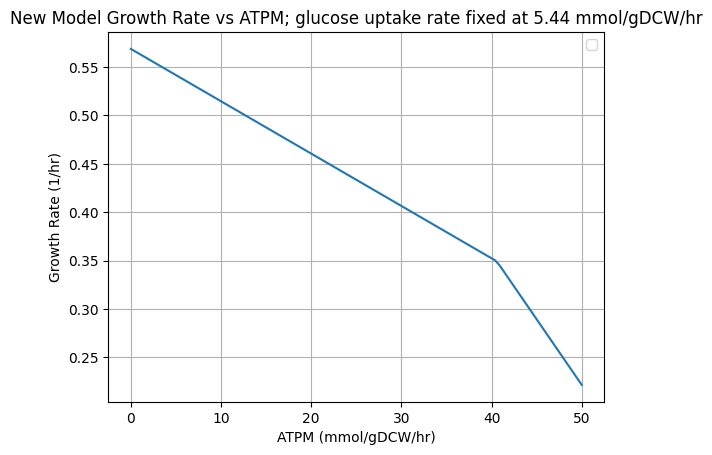

In [4]:
plt.plot(ATPM_space, growth_rates)
plt.title("New Model Growth Rate vs ATPM; glucose uptake rate fixed at 5.44 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()


In [5]:
glucose_and_acetate_space = np.linspace(0,30,100)
glucose_growth_rates = []
acetate_growth_rates = []
with model:
    for level in tqdm(glucose_and_acetate_space):
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-level, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        glucose_growth_rates.append(growth_rate)
        
        model.reactions.get_by_id("EX_ac").bounds = (-level, 0)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        acetate_growth_rates.append(growth_rate)

100%|██████████| 100/100 [00:02<00:00, 35.91it/s]


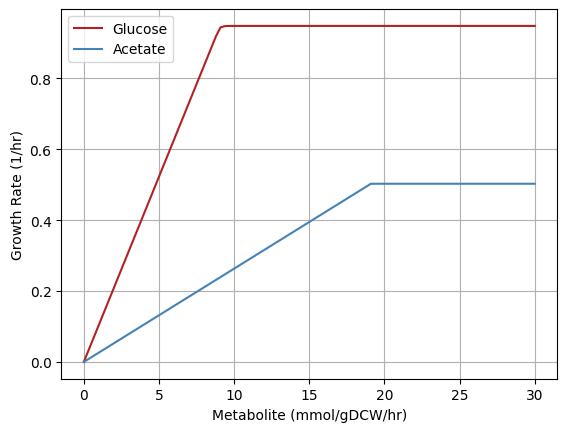

In [6]:
"""
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 4)) #

ax[0].plot(glucose_and_acetate_space, glucose_growth_rates, label="Glucose",color="firebrick")
ax[0].set_xlabel("Glucose (mmol/gDCW/hr)")
ax[0].set_ylabel("Growth Rate (1/hr)")
ax[0].grid()

ax[1].plot(glucose_and_acetate_space, acetate_growth_rates, label="Acetate", color="steelblue")
ax[1].set_xlabel("Acetate (mmol/gDCW/hr)")
ax[1].set_ylabel("Growth Rate (1/hr)")
ax[1].grid()
"""
plt.plot(glucose_and_acetate_space, glucose_growth_rates, label="Glucose",color="firebrick")
plt.plot(glucose_and_acetate_space, acetate_growth_rates, label="Acetate", color="steelblue")
plt.xlabel("Metabolite (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()


Glucose growth is too fast!

In [41]:
model.reactions.get_by_id("EX_glc").reaction


'Glucopyranose[e] --> '

In [43]:
m = model.metabolites.get_by_id("Glucopyranose[e]")
print(m.id, m.name, m.formula)
get_metabolite_reactions("Glucopyranose[e]")

Glucopyranose[e] D-glucopyranose C6H12O6
Consuming reactions:
	GLCtex: Glucopyranose[e] <=> Glucopyranose[p]
	EX_glc: Glucopyranose[e] --> 
Producing reactions:



([<Reaction GLCtex at 0x12825c5b0>, <Reaction EX_glc at 0x1282671c0>], [])

In [46]:
m = model.metabolites.get_by_id("Glucopyranose[p]")
print(m.id, m.name, m.formula)
_ = get_metabolite_reactions("Glucopyranose[p]")

my_id = "Glucopyranose[c]"
m = model.metabolites.get_by_id(my_id)
print(m.id, m.name, m.formula)
_ = get_metabolite_reactions(my_id)

Glucopyranose[p] D-glucopyranose C6H12O6
Consuming reactions:
	GLCtpp: ATP[c] + Glucopyranose[p] + WATER[c] --> ADP[c] + Glucopyranose[c] + PROTON[c] + Pi[c]
Producing reactions:
	GLCtex: Glucopyranose[e] <=> Glucopyranose[p]

Glucopyranose[c] D-glucopyranose C6H12O6
Consuming reactions:
	GLUCISOM-RXN: Glucopyranose[c] <=> CPD-15382[c]
	GLUCOKIN-RXN: ATP[c] + Glucopyranose[c] --> ADP[c] + D-glucopyranose-6-phosphate[c] + PROTON[c]
Producing reactions:
	GLCtpp: ATP[c] + Glucopyranose[p] + WATER[c] --> ADP[c] + Glucopyranose[c] + PROTON[c] + Pi[c]



In [47]:
model.reactions.get_by_id("ATPM")

Reaction identifier,ATPM
Name,ATPM
Memory address,0x12e090e20
Stoichiometry,ATP[c] + WATER[c] --> ADP[c] + PROTON[c] + Pi[c] ATP + H2O --> ADP + H+ + phosphate
GPR,
Lower bound,0.0
Upper bound,0.0


## comparing with e coli

In [19]:
ref_model = cobra.io.load_model("iJO1366")
ref_model.reactions.get_by_id("EX_glc__D_e").bounds = (-5.44, 0)
ref_sol = ref_model.optimize()
print(f"Reference iJO1366 growth rate: {ref_sol.objective_value:.4f} h⁻¹")

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("ATPM").bounds = (3.15, 3.15)
    custom_sol = model.optimize()
    print(f"Custom model growth rate: {custom_sol.objective_value:.4f} h⁻¹")
    print(f"Ratio (custom/ref): {custom_sol.objective_value / ref_sol.objective_value:.2f}x")


Reference iJO1366 growth rate: 0.5285 h⁻¹
Custom model growth rate: 0.5517 h⁻¹
Ratio (custom/ref): 1.04x


In [99]:
core_subsystems = [
    "Glycolysis", "Citric Acid Cycle", "Pentose Phosphate Pathway",
    "Oxidative Phosphorylation", "Pyruvate Metabolism",
    "Anaplerotic Reactions", "Gluconeogenesis",
]

ref_fluxes = ref_sol.fluxes
custom_fluxes = custom_sol.fluxes

shared_rxns = set(ref_fluxes.index) & set(custom_fluxes.index)
print(f"\nShared reactions: {len(shared_rxns)}")

flux_comparison = pd.DataFrame({
    "ref_flux": ref_fluxes[list(shared_rxns)],
    "custom_flux": custom_fluxes[list(shared_rxns)],
})
flux_comparison["abs_diff"] = (flux_comparison["custom_flux"] - flux_comparison["ref_flux"]).abs()
flux_comparison["ratio"] = flux_comparison["custom_flux"] / flux_comparison["ref_flux"].replace(0, np.nan)

rxn_subsystem = {}
for r in ref_model.reactions:
    if r.id in shared_rxns:
        rxn_subsystem[r.id] = r.subsystem
flux_comparison["subsystem"] = flux_comparison.index.map(rxn_subsystem)

print("\n=== CORE METABOLISM FLUX COMPARISON (top discrepancies) ===")
core_mask = flux_comparison["subsystem"].apply(
    lambda s: any(cs.lower() in str(s).lower() for cs in core_subsystems) if pd.notna(s) else False
)
core_diff = flux_comparison[core_mask].sort_values("abs_diff", ascending=False)
print(core_diff.head(46).to_string())

print("\n=== LARGEST FLUX DISCREPANCIES (all shared reactions) ===")
print(flux_comparison.sort_values("abs_diff", ascending=False).head(30).to_string())





Shared reactions: 46

=== CORE METABOLISM FLUX COMPARISON (top discrepancies) ===
Empty DataFrame
Columns: [ref_flux, custom_flux, abs_diff, ratio, subsystem]
Index: []

=== LARGEST FLUX DISCREPANCIES (all shared reactions) ===
                ref_flux  custom_flux      abs_diff         ratio                               subsystem
Htex       -4.855545e+00    88.493749  9.334929e+01 -1.822530e+01         Transport, Outer Membrane Porin
CO2tex     -1.094787e+01   -14.354870  3.406995e+00  1.311201e+00         Transport, Outer Membrane Porin
CO2tpp     -1.094787e+01   -14.354870  3.406995e+00  1.311201e+00               Transport, Inner Membrane
O2tex       9.820207e+00    12.674017  2.853810e+00  1.290606e+00         Transport, Outer Membrane Porin
O2tpp       9.820207e+00    12.674017  2.853810e+00  1.290606e+00  Inorganic Ion Transport and Metabolism
H2Otpp     -2.490418e+01   -22.886846  2.017336e+00  9.189961e-01               Transport, Inner Membrane
H2Otex     -2.490418e+01   -2

<table class="flux-table">
    <thead>
        <tr>
            <th>Reaction ID</th>
            <th>Ref Flux</th>
            <th>Custom Flux</th>
            <th>Abs Diff</th>
            <th>Ratio</th>
            <th>Subsystem</th>
        </tr>
    </thead>
    <tbody>
        <tr><td><b>Htex</b></td><td>-4.8555</td><td>88.4937</td><td>93.3493</td><td>-18.2253</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>CO2tex</b></td><td>-10.9479</td><td>-14.3549</td><td>3.4070</td><td>1.3112</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>CO2tpp</b></td><td>-10.9479</td><td>-14.3549</td><td>3.4070</td><td>1.3112</td><td>Transport, Inner Membrane</td></tr>
        <tr><td><b>O2tex</b></td><td>9.8202</td><td>12.6740</td><td>2.8538</td><td>1.2906</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>O2tpp</b></td><td>9.8202</td><td>12.6740</td><td>2.8538</td><td>1.2906</td><td>Inorganic Ion Transport and Metabolism</td></tr>
        <tr><td><b>H2Otex</b></td><td>-24.9042</td><td>-22.8868</td><td>2.0173</td><td>0.9190</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>H2Otpp</b></td><td>-24.9042</td><td>-22.8868</td><td>2.0173</td><td>0.9190</td><td>Transport, Inner Membrane</td></tr>
        <tr><td><b>NH4tex</b></td><td>5.7077</td><td>4.0930</td><td>1.6147</td><td>0.7171</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>PItex</b></td><td>0.5098</td><td>0.2457</td><td>0.2640</td><td>0.4820</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>SO4tex</b></td><td>0.1333</td><td>0.1153</td><td>0.0180</td><td>0.8648</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>FE2tex</b></td><td>0.0085</td><td>0.0038</td><td>0.0047</td><td>0.4509</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>FE2tpp</b></td><td>0.0085</td><td>0.0038</td><td>0.0047</td><td>0.4509</td><td>Inorganic Ion Transport and Metabolism</td></tr>
        <tr><td><b>Ktex</b></td><td>0.1032</td><td>0.1077</td><td>0.0045</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>FE3tex</b></td><td>-9.75e-19</td><td>0.0043</td><td>0.0043</td><td>-4.42e+15</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>MG2tex</b></td><td>0.0046</td><td>0.0048</td><td>2.01e-04</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>THMtex</b></td><td>0.0000</td><td>1.23e-04</td><td>1.23e-04</td><td>NaN</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>CLtex</b></td><td>0.0028</td><td>0.0029</td><td>1.21e-04</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>CA2tex</b></td><td>0.0028</td><td>0.0029</td><td>1.21e-04</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>MOBDtex</b></td><td>6.82e-05</td><td>3.86e-06</td><td>6.43e-05</td><td>0.0566</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>CU2tex</b></td><td>3.75e-04</td><td>3.91e-04</td><td>1.65e-05</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>MNtex</b></td><td>3.65e-04</td><td>3.81e-04</td><td>1.60e-05</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>Zn2tex</b></td><td>1.80e-04</td><td>1.88e-04</td><td>7.91e-06</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>NI2tex</b></td><td>1.71e-04</td><td>1.78e-04</td><td>7.50e-06</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>COBALT2tex</b></td><td>1.32e-05</td><td>1.38e-05</td><td>5.80e-07</td><td>1.0439</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>PYRtex</b></td><td>6.74e-16</td><td>0.0000</td><td>6.74e-16</td><td>0.0000</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>ACtex</b></td><td>-3.97e-17</td><td>0.0000</td><td>3.97e-17</td><td>0.0000</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>LIPOtex</b></td><td>0.0000</td><td>0.0000</td><td>0.0000</td><td>NaN</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>MANtex</b></td><td>0.0000</td><td>0.0000</td><td>0.0000</td><td>NaN</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>PYDXNtex</b></td><td>0.0000</td><td>0.0000</td><td>0.0000</td><td>NaN</td><td>Transport, Outer Membrane Porin</td></tr>
        <tr><td><b>PYDXNtpp</b></td><td>0.0000</td><td>0.0000</td><td>0.0000</td><td>NaN</td><td>Transport, Inner Membrane</td></tr>
    </tbody>
</table>

**Htex is certainly worth investigating**

In [100]:
# ─── 2. Biomass composition comparison (with name mapping) ────────────────────

# Mapping from custom model metabolite IDs to iJO1366 equivalents
# Add/edit entries as needed for your model's naming convention
custom_to_bigg = {
    "ATP[c]": "atp_c",
    "ADP[c]": "adp_c",
    "WATER[c]": "h2o_c",
    "PROTON[c]": "h_c",
    "Pi[c]": "pi_c",
    "NAD[c]": "nad_c",
    "NADP[c]": "nadp_c",
    # Macromolecule pseudo-metabolites (no direct iJO1366 equivalent)
    # "PROTEIN[c]": None,
    # "LIPID[c]": None,
    # "RNA[c]": None,
    # "DNA[c]": None,
    # "MUREIN[c]": None,
    # "PHB-STORAGE[c]": None,
    # "IONS[c]": None,
    # "COFACTORS[c]": None,
}

# Also try to auto-match by metabolite name/formula
def build_auto_mapping(custom_model, ref_model):
    """Try to match metabolites by name or formula when IDs differ."""
    ref_by_name = {}
    ref_by_formula = {}
    for m in ref_model.metabolites:
        if m.name:
            ref_by_name[m.name.lower().strip()] = m.id
        if m.formula:
            ref_by_formula[(m.formula, m.compartment)] = m.id

    auto_map = {}
    for m in custom_model.metabolites:
        if m.id in custom_to_bigg:
            continue  # already mapped manually
        # Try name match
        if m.name and m.name.lower().strip() in ref_by_name:
            auto_map[m.id] = ref_by_name[m.name.lower().strip()]
        # Try formula + compartment match
        elif m.formula:
            compartment = m.compartment if m.compartment else "c"
            key = (m.formula, compartment)
            if key in ref_by_formula:
                auto_map[m.id] = ref_by_formula[key]
    return auto_map

auto_map = build_auto_mapping(model, ref_model)
print(f"Auto-matched {len(auto_map)} additional metabolites by name/formula")

# Merge mappings (manual takes precedence)
full_mapping = {**auto_map, **custom_to_bigg}

# Get biomass reactions
def get_biomass_rxn(m):
    obj_rxns = [r for r in m.reactions if r.objective_coefficient != 0]
    if obj_rxns:
        return obj_rxns[0]
    for r in m.reactions:
        if "biomass" in r.id.lower():
            return r
    return None

ref_biomass = get_biomass_rxn(ref_model)
custom_biomass = get_biomass_rxn(model)

print(f"\nReference biomass: {ref_biomass.id}")
print(f"Custom biomass:    {custom_biomass.id}")

# Build coefficient dicts using mapped IDs where possible
ref_bm_mets = {m.id: coeff for m, coeff in ref_biomass.metabolites.items()}

custom_bm_mets_raw = {m.id: coeff for m, coeff in custom_biomass.metabolites.items()}
custom_bm_mets_mapped = {}
custom_unmapped = {}
for met_id, coeff in custom_bm_mets_raw.items():
    mapped_id = full_mapping.get(met_id)
    if mapped_id:
        custom_bm_mets_mapped[mapped_id] = coeff
    else:
        custom_unmapped[met_id] = coeff

# Compare mapped metabolites
all_mapped_ids = set(ref_bm_mets.keys()) | set(custom_bm_mets_mapped.keys())

biomass_comp = pd.DataFrame({
    "ref_coeff": {m: ref_bm_mets.get(m, 0) for m in all_mapped_ids},
    "custom_coeff": {m: custom_bm_mets_mapped.get(m, 0) for m in all_mapped_ids},
})
biomass_comp["diff"] = biomass_comp["custom_coeff"] - biomass_comp["ref_coeff"]
biomass_comp["abs_diff"] = biomass_comp["diff"].abs()

# Show the ATP/ADP/H2O/Pi comparison specifically
print("\n=== GAM (Growth-Associated Maintenance) COMPARISON ===")
gam_mets = ["atp_c", "adp_c", "h2o_c", "h_c", "pi_c"]
gam_in_comp = biomass_comp.loc[biomass_comp.index.isin(gam_mets)]
print(gam_in_comp.to_string())

ref_gam = abs(ref_bm_mets.get("atp_c", 0))
custom_gam = abs(custom_bm_mets_mapped.get("atp_c", 0))
print(f"\nGAM ATP cost:  reference = {ref_gam:.2f},  custom = {custom_gam:.2f} mmol/gDW")
if custom_gam < ref_gam * 0.8:
    print("  ⚠ Custom GAM is significantly lower — growth will be cheaper!")
elif custom_gam > ref_gam * 1.2:
    print("  ⚠ Custom GAM is significantly higher than reference.")
else:
    print("  ✓ GAM costs are in reasonable agreement.")

# Shared metabolites with largest differences (excluding GAM)
print("\n=== NON-GAM BIOMASS DIFFERENCES (mapped metabolites) ===")
non_gam = biomass_comp[~biomass_comp.index.isin(gam_mets)]
shared = non_gam[(non_gam["ref_coeff"] != 0) & (non_gam["custom_coeff"] != 0)]
print(shared.sort_values("abs_diff", ascending=False).head(20).to_string())

# Only in reference (missing from custom)
only_ref = non_gam[(non_gam["custom_coeff"] == 0) & (non_gam["ref_coeff"] != 0)]
print(f"\nMetabolites only in reference biomass ({len(only_ref)}):")
print(only_ref.sort_values("abs_diff", ascending=False).head(15).to_string())

# Unmapped custom metabolites (macromolecule pseudometabolites etc.)
print(f"\n=== UNMAPPED CUSTOM BIOMASS COMPONENTS ({len(custom_unmapped)}) ===")
print("(No direct iJO1366 equivalent — likely macromolecule pseudometabolites)")
unmapped_df = pd.DataFrame.from_dict(custom_unmapped, orient="index", columns=["coeff"])
print(unmapped_df.sort_values("coeff").to_string())

# Total precursor cost comparison (mapped only)
ref_total = sum(v for v in ref_bm_mets.values() if v < 0)
custom_total_mapped = sum(v for v in custom_bm_mets_mapped.values() if v < 0)
custom_total_all = sum(v for v in custom_bm_mets_raw.values() if v < 0)
print(f"\nTotal precursor drain (sum of negative coeffs):")
print(f"  Reference:             {ref_total:.4f}")
print(f"  Custom (mapped only):  {custom_total_mapped:.4f}")
print(f"  Custom (all):          {custom_total_all:.4f}")

Auto-matched 821 additional metabolites by name/formula

Reference biomass: BIOMASS_Ec_iJO1366_core_53p95M
Custom biomass:    Rpom_hwa_biomass

=== GAM (Growth-Associated Maintenance) COMPARISON ===
       ref_coeff  custom_coeff       diff   abs_diff
pi_c   53.945662     31.357458 -22.588204  22.588204
h_c    53.950000     31.361796 -22.588204  22.588204
h2o_c -48.601527    -48.601527   0.000000   0.000000
adp_c  53.950000     31.361796 -22.588204  22.588204
atp_c -54.124831    -31.361795  22.763036  22.763036

GAM ATP cost:  reference = 54.12,  custom = 31.36 mmol/gDW
  ⚠ Custom GAM is significantly lower — growth will be cheaper!

=== NON-GAM BIOMASS DIFFERENCES (mapped metabolites) ===
        ref_coeff  custom_coeff  diff  abs_diff
nad_c   -0.001831     -0.001831   0.0       0.0
nadp_c  -0.000447     -0.000447   0.0       0.0

Metabolites only in reference biomass (65):
          ref_coeff  custom_coeff      diff  abs_diff
ppi_c      0.773903           0.0 -0.773903  0.773903
gly_

In [103]:
model.reactions.get_by_id("Rpom_hwa_biomass").reaction

'31.36179486 ATP[c] + 0.001524574 COFACTORS[c] + 0.05136379 DNA[c] + 0.009825009 IONS[c] + 0.095950926 LIPID[c] + 0.026355529 MUREIN[c] + 0.000447 NADP[c] + 0.001831 NAD[c] + 0.091372857 PHB-STORAGE[c] + 0.561521914 PROTEIN[c] + 0.093597842 RNA[c] + 48.601527 WATER[c] --> 31.36179573 ADP[c] + 31.36179573 PROTON[c] + 31.35745773 Pi[c]'

In [105]:
ref_model.reactions.get_by_id("BIOMASS_Ec_iJO1366_core_53p95M").reaction

'0.000223 10fthf_c + 2.6e-05 2fe2s_c + 0.000223 2ohph_c + 0.00026 4fe4s_c + 0.513689 ala__L_c + 0.000223 amet_c + 0.295792 arg__L_c + 0.241055 asn__L_c + 0.241055 asp__L_c + 54.124831 atp_c + 0.000122 bmocogdp_c + 2e-06 btn_c + 0.005205 ca2_c + 0.005205 cl_c + 0.000576 coa_c + 2.5e-05 cobalt2_c + 0.133508 ctp_c + 0.000709 cu2_c + 0.09158 cys__L_c + 0.026166 datp_c + 0.027017 dctp_c + 0.027017 dgtp_c + 0.026166 dttp_c + 0.000223 fad_c + 0.006715 fe2_c + 0.007808 fe3_c + 0.26316 gln__L_c + 0.26316 glu__L_c + 0.612638 gly_c + 0.215096 gtp_c + 48.601527 h2o_c + 0.094738 his__L_c + 0.290529 ile__L_c + 0.195193 k_c + 0.019456 kdo2lipid4_e + 0.450531 leu__L_c + 0.343161 lys__L_c + 0.153686 met__L_c + 0.008675 mg2_c + 0.000223 mlthf_c + 0.000691 mn2_c + 7e-06 mobd_c + 0.013894 murein5px4p_p + 0.001831 nad_c + 0.000447 nadp_c + 0.013013 nh4_c + 0.000323 ni2_c + 0.017868 pe160_c + 0.045946 pe160_p + 0.054154 pe161_c + 0.02106 pe161_p + 0.185265 phe__L_c + 0.000223 pheme_c + 0.221055 pro__L_c + 0

In [121]:
# ─── Patch GAM to match iJO1366 
# WARNING: This will modify model variable. 

custom_biomass = get_biomass_rxn(model)

# Current GAM coefficients in your model
gam_mapping = {
    "ATP[c]": "atp_c",
    "ADP[c]": "adp_c",
    "WATER[c]": "h2o_c",
    "PROTON[c]": "h_c",
    "Pi[c]": "pi_c",
}

# Target coefficients from iJO1366 BIOMASS_Ec_iJO1366_core_53p95M
ref_gam_coeffs = {
    "atp_c": -54.124831,
    "adp_c":  53.950000,
    "h2o_c": -48.601527,  # already matches
    "h_c":    53.950000,
    "pi_c":   53.945662,
}

# Build the delta to add
print("=== PATCHING GAM COEFFICIENTS ===")
for custom_id, bigg_id in gam_mapping.items():
    met = model.metabolites.get_by_id(custom_id)
    current = custom_biomass.metabolites.get(met, 0)
    target = ref_gam_coeffs[bigg_id]
    delta = target - current
    if abs(delta) > 1e-6:
        print(f"  {custom_id:12s}: {current:10.4f} → {target:10.4f}  (Δ = {delta:+.4f})")
        custom_biomass.add_metabolites({met: delta})
    else:
        print(f"  {custom_id:12s}: {current:10.4f} (unchanged)")

# ─── Re-run with both ATPM + corrected GAM ───────────────────────────────────

model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

sol_patched = model.optimize()
print(f"\n=== RESULTS AFTER ATPM + GAM CORRECTION ===")
print(f"Patched growth rate:   {sol_patched.objective_value:.4f} h⁻¹")
print(f"Reference (iJO1366):   {ref_sol.objective_value:.4f} h⁻¹")
print(f"Ratio:                 {sol_patched.objective_value / ref_sol.objective_value:.2f}x")

# ─── Quick check: how much did each fix contribute? ──────────────────────────

# ATPM only (undo GAM patch temporarily)
with model:
    # Revert GAM to original values
    for custom_id, bigg_id in gam_mapping.items():
        met = model.metabolites.get_by_id(custom_id)
        current = custom_biomass.metabolites.get(met, 0)
        original_custom = {
            "ATP[c]": -31.361795,
            "ADP[c]":  31.361796,
            "WATER[c]": -48.601527,
            "PROTON[c]": 31.361796,
            "Pi[c]":   31.357458,
        }
        delta = original_custom[custom_id] - current
        custom_biomass.add_metabolites({met: delta})

    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    sol_atpm_only = model.optimize()
    print(f"\nATPM fix only:         {sol_atpm_only.objective_value:.4f} h⁻¹")

print(f"GAM fix contribution:  {sol_atpm_only.objective_value - sol_patched.objective_value:.4f} h⁻¹ reduction")

=== PATCHING GAM COEFFICIENTS ===
  ATP[c]      :   -31.3618 →   -54.1248  (Δ = -22.7630)
  ADP[c]      :    31.3618 →    53.9500  (Δ = +22.5882)
  WATER[c]    :   -48.6015 (unchanged)
  PROTON[c]   :    31.3618 →    53.9500  (Δ = +22.5882)
  Pi[c]       :    31.3575 →    53.9457  (Δ = +22.5882)

=== RESULTS AFTER ATPM + GAM CORRECTION ===
Patched growth rate:   0.4898 h⁻¹
Reference (iJO1366):   0.5285 h⁻¹
Ratio:                 0.93x

ATPM fix only:         0.5687 h⁻¹
GAM fix contribution:  0.0789 h⁻¹ reduction


adjusting coefficients in biomass reaction:
- ATP consumed: 31.36 → 54.12 (more ATP burned per gram of biomass)
- ADP produced: 31.36 → 53.95 (corresponding hydrolysis products)
- H⁺ produced: 31.36 → 53.95
- Pi produced: 31.36 → 53.95

ATPM + GAM fix together brought growth to 0.4898 h⁻¹, which is 0.93× the reference. 

GAM fix accounts for a 0.0789 h⁻¹ reduction.

In [106]:
# ─── 3. Sensitivity analysis: growth rate vs biomass components ───────────────

print("\n=== BIOMASS COMPONENT SENSITIVITY ANALYSIS ===")
print("Perturbing each biomass reactant by ±10% and measuring growth rate change.\n")

base_growth = custom_sol.objective_value
sensitivities = []

reactants = {m: c for m, c in custom_biomass.metabolites.items() if c < 0}

for met, orig_coeff in reactants.items():
    results = {}
    for label, factor in [("-10%", 0.9), ("+10%", 1.1)]:
        with model:
            model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
            custom_biomass.add_metabolites({met: orig_coeff * factor - orig_coeff})
            sol = model.optimize()
            gr = sol.objective_value if sol.status == "optimal" else 0.0
            results[label] = gr

    delta_gr = results["+10%"] - results["-10%"]
    sensitivity = delta_gr / (0.2 * abs(orig_coeff))  # normalized sensitivity
    pct_change = (results["+10%"] - base_growth) / base_growth * 100 if base_growth else 0

    sensitivities.append({
        "metabolite": met.id,
        "name": met.name,
        "orig_coeff": orig_coeff,
        "gr_minus10": results["-10%"],
        "gr_plus10": results["+10%"],
        "delta_gr": delta_gr,
        "pct_change_at_plus10": pct_change,
        "normalized_sensitivity": sensitivity,
    })

sens_df = pd.DataFrame(sensitivities)
sens_df["abs_sensitivity"] = sens_df["normalized_sensitivity"].abs()
sens_df = sens_df.sort_values("abs_sensitivity", ascending=False)

print("Top 25 most sensitive biomass components:")
print(sens_df.head(25).to_string(index=False))

print("\n=== SUSPICIOUSLY INSENSITIVE COMPONENTS ===")
print("(Large biomass drain but near-zero growth sensitivity — possible bypass or free lunch)\n")
sens_df["cost_rank"] = sens_df["orig_coeff"].rank()
insensitive_but_costly = sens_df[
    (sens_df["abs_sensitivity"] < sens_df["abs_sensitivity"].quantile(0.25)) &
    (sens_df["orig_coeff"] < sens_df["orig_coeff"].quantile(0.25))
]
print(insensitive_but_costly[
    ["metabolite", "name", "orig_coeff", "pct_change_at_plus10", "normalized_sensitivity"]
].to_string(index=False))

if len(insensitive_but_costly) > 0:
    print("\n⚠ These metabolites are heavily consumed by biomass but growth barely changes")
    print("  when you increase demand — likely means the biosynthesis pathway is too cheap")
    print("  or there's an unconstrained shortcut producing them for free.")


=== BIOMASS COMPONENT SENSITIVITY ANALYSIS ===
Perturbing each biomass reactant by ±10% and measuring growth rate change.

Top 25 most sensitive biomass components:
    metabolite  name  orig_coeff  gr_minus10  gr_plus10      delta_gr  pct_change_at_plus10  normalized_sensitivity  abs_sensitivity
      LIPID[c]         -0.095951    0.576718   0.560885 -1.583309e-02              1.672459           -8.250618e-01     8.250618e-01
  COFACTORS[c]         -0.001525    0.568778   0.568606 -1.722407e-04              3.071920           -5.648813e-01     5.648813e-01
    PROTEIN[c]         -0.561522    0.602032   0.538850 -6.318217e-02             -2.321893           -5.625976e-01     5.625976e-01
PHB-STORAGE[c]         -0.091373    0.572850   0.564594 -8.256267e-03              2.344648           -4.517899e-01     4.517899e-01
       NADP[c] NADP+   -0.000447    0.568703   0.568680 -2.339764e-05              3.085408           -2.617185e-01     2.617185e-01
        DNA[c]         -0.051364    

$\text{sensitivity} = \frac{\mu_{+10\%} - \mu_{-10\%}}{0.2 \times |c_i|}$

The most sensitive components which constrain model growth:

- LIPID (sensitivity 0.83) — lipid biosynthesis is the tightest bottleneck (NADPH expensive). Increasing lipid demand by 10% causes the biggest growth drop. 
- COFACTORS (0.56) and PROTEIN (0.56) also significant.
- PHB-STORAGE (0.45) — polyhydroxybutyrate storage granules are moderately costly.

- ATP has modest has a small normalized sensitivity (0.12) but a big absolute effect: ±10% on 31.36 mmol swings growth from 1.12 to 0.33 h⁻¹.
- why are MUREIN and IONS nearly insensitive?

## 1. Compare growth rate ratios across carbon sources

In [123]:
carbon_sources = {
    ("EX_glc", "EX_glc__D_e"): (-5.44, 0, "Glucose"),
    ("EX_ac", "EX_ac_e"):  (-10.0, 0, "Acetate"),  # adjust uptake rate as appropriate
    ("EX_succ", "EX_succ_e"): (-10.0, 0, "Succinate"),
}

print("=== GROWTH ON DIFFERENT CARBON SOURCES ===")
for (ex_rxn, ex_rxn_bigg), (lb, ub, name) in carbon_sources.items():
    # Shut off all carbon sources, then enable one
    with model:
        for ex_id in carbon_sources:
            ex_id = ex_id[0]
            try:
                model.reactions.get_by_id(ex_id).bounds = (0, 0)
            except KeyError:
                pass
        model.reactions.get_by_id(ex_rxn).bounds = (lb, ub)
        sol = model.optimize()
        custom_gr = sol.objective_value if sol.status == "optimal" else 0.0

    with ref_model:
        for ex_id in carbon_sources:
            ex_id = ex_id[1]
            try:
                ref_model.reactions.get_by_id(ex_id).bounds = (0, 0)
            except KeyError:
                pass
        ref_model.reactions.get_by_id(ex_rxn_bigg).bounds = (lb, ub)
        ref_sol_cs = ref_model.optimize()
        ref_gr = ref_sol_cs.objective_value if ref_sol_cs.status == "optimal" else 0.0

    ratio = custom_gr / ref_gr if ref_gr else float('inf')
    print(f"  {name:12s}: custom={custom_gr:.4f}  ref={ref_gr:.4f}  ratio={ratio:.2f}x")

=== GROWTH ON DIFFERENT CARBON SOURCES ===
  Glucose     : custom=0.5687  ref=0.5285  ratio=1.08x
  Acetate     : custom=0.2633  ref=0.2472  ratio=1.07x
  Succinate   : custom=0.5659  ref=0.4925  ratio=1.15x


In [124]:
# After solving on glucose
model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
sol = model.optimize()

print("\n=== CARBON BALANCE (glucose growth) ===")
glc_uptake = abs(sol.fluxes.get("EX_glc", 0))
co2_export = abs(sol.fluxes.get("EX_co2", sol.fluxes.get("EX_CO2", 0)))
ac_export = abs(sol.fluxes.get("EX_ac", sol.fluxes.get("EX_ACET", 0)))

carbon_in = glc_uptake * 6  # glucose has 6 carbons
carbon_out_co2 = co2_export * 1
carbon_out_ac = ac_export * 2

print(f"  Carbon in (glucose):  {carbon_in:.2f} C-mmol/gDW/hr")
print(f"  Carbon out (CO2):     {carbon_out_co2:.2f}")
print(f"  Carbon out (acetate): {carbon_out_ac:.2f}")
print(f"  Carbon to biomass:    {carbon_in - carbon_out_co2 - carbon_out_ac:.2f} (by difference)")
print(f"  Biomass carbon yield: {(carbon_in - carbon_out_co2 - carbon_out_ac) / carbon_in:.1%}")


=== CARBON BALANCE (glucose growth) ===
  Carbon in (glucose):  32.64 C-mmol/gDW/hr
  Carbon out (CO2):     13.79
  Carbon out (acetate): 0.00
  Carbon to biomass:    18.85 (by difference)
  Biomass carbon yield: 57.8%


In [125]:
# Scan for unrealistic ATP-generating reactions
print("\n=== TOP ATP-PRODUCING REACTIONS ===")
atp_producers = []
for rxn in model.reactions:
    flux = sol.fluxes[rxn.id]
    if abs(flux) < 1e-6:
        continue
    for met, coeff in rxn.metabolites.items():
        if "ATP" in met.id and "[c]" in met.id:
            atp_rate = coeff * flux
            if atp_rate > 0.1:  # net ATP production
                atp_producers.append((rxn.id, rxn.name, flux, atp_rate))

atp_df = pd.DataFrame(atp_producers, columns=["rxn_id", "name", "flux", "atp_produced"])
atp_df = atp_df.sort_values("atp_produced", ascending=False)
print(atp_df.head(20).to_string(index=False))
print(f"\nTotal ATP produced: {atp_df['atp_produced'].sum():.2f} mmol/gDW/hr")
print(f"ATP per glucose:    {atp_df['atp_produced'].sum() / glc_uptake:.1f}")


=== TOP ATP-PRODUCING REACTIONS ===
                             rxn_id                                name       flux  atp_produced
                         ATPSYN-RXN                          ATPSYN-RXN -32.756264     32.756264
                  FORMATETHFLIG-RXN                   FORMATETHFLIG-RXN  -5.228341      5.228341
                    PHOSGLYPHOS-RXN                     PHOSGLYPHOS-RXN  -4.960516      4.960516
PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN  -1.380397      1.380397
             MALATE--COA-LIGASE-RXN              MALATE--COA-LIGASE-RXN  -0.767752      0.767752
                     SUCCCOASYN-RXN                      SUCCCOASYN-RXN  -0.487418      0.487418
                     ADENYL-KIN-RXN                      ADENYL-KIN-RXN  -0.223549      0.223549

Total ATP produced: 45.80 mmol/gDW/hr
ATP per glucose:    8.4


PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN should not be producing ATP... Used in gluconeogenesis to generate glucose, eating up ATP

In [128]:
model.reactions.get_by_id("PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN").reaction

'ATP[c] + PYRUVATE[c] + Pi[c] <=> AMP[c] + PHOSPHO-ENOL-PYRUVATE[c] + PPI[c] + PROTON[c]'

In [135]:
with model:
    model.reactions.get_by_id("PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN").bounds = (0, 1000)
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

    sol = model.optimize()
    growth_rate = sol.objective_value
    print(f"Growth rate: {growth_rate:.4f} h⁻¹")
    
    # further testing does not reveal differences

Growth rate: 0.5628 h⁻¹


glycolytic pathways

In [136]:
# Check which glycolytic routes are active
glycolysis_markers = {
    "EMP (pfk)": ["PHOSPHOFRUCTOKIN-RXN", "6PFRUCTPHOS-RXN", "PFK"],
    "ED pathway": ["PGLUCONDEHYDRAT-RXN", "2-DEHYDRO-3-DEOXY-6-PHOSPHOGLUCONATE-ALDOLASE-RXN",
                    "EDD", "EDA", "KDPGALDOL-RXN"],
    "Pentose phosphate": ["GLU6PDEHYDROG-RXN", "6PGLUCONOLACT-RXN", "GND"],
}

model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
sol_glc = model.optimize()

print("=== GLYCOLYTIC ROUTE USAGE ===")
for pathway, rxn_ids in glycolysis_markers.items():
    active = []
    for rid in rxn_ids:
        try:
            f = sol_glc.fluxes[rid]
            if abs(f) > 1e-6:
                active.append((rid, f))
        except KeyError:
            pass
    print(f"\n{pathway}:")
    if active:
        for rid, f in active:
            print(f"  {rid}: {f:.4f}")
    else:
        print("  (no flux or not in model)")

=== GLYCOLYTIC ROUTE USAGE ===

EMP (pfk):
  (no flux or not in model)

ED pathway:
  PGLUCONDEHYDRAT-RXN: 5.0546
  KDPGALDOL-RXN: 5.0546

Pentose phosphate:
  GLU6PDEHYDROG-RXN: 5.0546
  6PGLUCONOLACT-RXN: 5.0546


In [137]:
print("\n=== ATP YIELD PER CARBON ATOM ===")
for label, ex_id, n_carbon in [("Glucose", "EX_glc", 6), ("Acetate", "EX_ac", 2)]:
    with model:
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        try:
            model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        except KeyError:
            model.reactions.get_by_id("EX_ACET").bounds = (0, 0)
        model.reactions.get_by_id(ex_id).bounds = (-10.0, 0)
        sol = model.optimize()

        uptake = abs(sol.fluxes[ex_id])
        carbon_in = uptake * n_carbon

        atp_total = 0
        for rxn in model.reactions:
            flux = sol.fluxes[rxn.id]
            if abs(flux) < 1e-6:
                continue
            for met, coeff in rxn.metabolites.items():
                if "ATP" in met.id and "[c]" in met.id:
                    atp_rate = coeff * flux
                    if atp_rate > 0:
                        atp_total += atp_rate

        print(f"  {label}: uptake={uptake:.2f}, C-in={carbon_in:.1f}, "
              f"ATP={atp_total:.1f}, ATP/C={atp_total/carbon_in:.2f}")


=== ATP YIELD PER CARBON ATOM ===
  Glucose: uptake=9.43, C-in=56.6, ATP=76.9, ATP/C=1.36
  Acetate: uptake=10.00, C-in=20.0, ATP=44.3, ATP/C=2.21


In [138]:
# ─── Compare flux maps: glucose vs acetate ────────────────────────────────────

# Solve on glucose
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    try:
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    except KeyError:
        model.reactions.get_by_id("EX_ACET").bounds = (0, 0)
    sol_glc = model.optimize()
    fluxes_glc = sol_glc.fluxes.copy()

# Solve on acetate
with model:
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    try:
        model.reactions.get_by_id("EX_ac").bounds = (-10.0, 0)
    except KeyError:
        model.reactions.get_by_id("EX_ACET").bounds = (-10.0, 0)
    sol_ac = model.optimize()
    fluxes_ac = sol_ac.fluxes.copy()

# ─── 1. Reactions active ONLY on glucose (not on acetate) ─────────────────────
print("=== REACTIONS ACTIVE ONLY ON GLUCOSE (|flux| > 0.1) ===")
glc_only = []
for rxn_id in fluxes_glc.index:
    fg = fluxes_glc[rxn_id]
    fa = fluxes_ac.get(rxn_id, 0)
    if abs(fg) > 0.1 and abs(fa) < 1e-6:
        rxn = model.reactions.get_by_id(rxn_id)
        glc_only.append((rxn_id, fg, rxn.reaction))
        
glc_only_df = pd.DataFrame(glc_only, columns=["rxn_id", "glc_flux", "reaction"])
glc_only_df["abs_flux"] = glc_only_df["glc_flux"].abs()
glc_only_df = glc_only_df.sort_values("abs_flux", ascending=False)
print(glc_only_df.head(30).to_string(index=False))

# ─── 2. Reactions with largest flux INCREASE on glucose vs acetate ────────────
print("\n=== LARGEST FLUX INCREASES ON GLUCOSE vs ACETATE ===")
shared = set(fluxes_glc.index) & set(fluxes_ac.index)
diffs = []
for rxn_id in shared:
    fg = fluxes_glc[rxn_id]
    fa = fluxes_ac[rxn_id]
    if abs(fg) > 0.1 or abs(fa) > 0.1:
        diffs.append((rxn_id, fg, fa, fg - fa))

diff_df = pd.DataFrame(diffs, columns=["rxn_id", "glc_flux", "ac_flux", "diff"])
diff_df["abs_diff"] = diff_df["diff"].abs()
diff_df = diff_df.sort_values("abs_diff", ascending=False)
print(diff_df.head(30).to_string(index=False))

# ─── 3. Net cofactor production: glucose vs acetate ───────────────────────────
print("\n=== NET COFACTOR PRODUCTION (glucose vs acetate) ===")
cofactors = {
    "ATP": ["ATP[c]"],
    "NADH": ["NADH[c]", "NADH-P-OR-NOP[c]"],
    "NADPH": ["NADPH[c]"],
    "FADH2": ["FADH2[c]"],
}

for label, met_ids in cofactors.items():
    for condition, fluxes in [("Glucose", fluxes_glc), ("Acetate", fluxes_ac)]:
        total_prod = 0
        total_cons = 0
        for rxn in model.reactions:
            flux = fluxes[rxn.id]
            if abs(flux) < 1e-6:
                continue
            for met, coeff in rxn.metabolites.items():
                if met.id in met_ids:
                    rate = coeff * flux
                    if rate > 0:
                        total_prod += rate
                    else:
                        total_cons += rate
        print(f"  {label:8s} {label:6s}: produced={total_prod:7.2f}  consumed={total_cons:7.2f}  net={total_prod+total_cons:+.2f}")
    print()

# ─── 4. Is glucose uptake rate realistic? ─────────────────────────────────────
print("=== GLUCOSE UPTAKE SANITY CHECK ===")
print(f"  Glucose uptake: {abs(fluxes_glc['EX_glc']):.2f} mmol/gDW/hr")
print(f"  Acetate uptake: {abs(fluxes_ac.get('EX_ac', fluxes_ac.get('EX_ACET', 0))):.2f} mmol/gDW/hr")
print(f"  Glucose C-flux: {abs(fluxes_glc['EX_glc']) * 6:.1f} C-mmol/gDW/hr")
print(f"  Acetate C-flux: {abs(fluxes_ac.get('EX_ac', fluxes_ac.get('EX_ACET', 0))) * 2:.1f} C-mmol/gDW/hr")

=== REACTIONS ACTIVE ONLY ON GLUCOSE (|flux| > 0.1) ===
             rxn_id  glc_flux                                                                                           reaction  abs_flux
             GLCtpp  5.440000             ATP[c] + Glucopyranose[p] + WATER[c] --> ADP[c] + Glucopyranose[c] + PROTON[c] + Pi[c]  5.440000
             EX_glc -5.440000                                                                              Glucopyranose[e] <--   5.440000
             GLCtex  5.440000                                                              Glucopyranose[e] <=> Glucopyranose[p]  5.440000
          RXN-20084 -5.112390         GLT[c] + NADP[c] + WATER[c] <-- 2-KETOGLUTARATE[c] + AMMONIA[c] + NADPH[c] + 2.0 PROTON[c]  5.112390
  6PGLUCONOLACT-RXN  5.054631                              D-6-P-GLUCONO-DELTA-LACTONE[c] + WATER[c] --> CPD-2961[c] + PROTON[c]  5.054631
  GLU6PDEHYDROG-RXN  5.054631 D-glucopyranose-6-phosphate[c] + NADP[c] --> D-6-P-GLUCONO-DELTA-LACTONE[c] + NA

In [141]:
# ─── Biomass yield per carbon: glucose vs acetate ─────────────────────────────

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    glc_yield = sol_glc.objective_value / (5.44 * 6)  # gDW per C-mmol
    print(f"Glucose:  growth={sol_glc.objective_value:.4f}  yield={glc_yield:.5f} gDW/C-mmol")

with model:
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-10.0, 0)
    sol_ac = model.optimize()
    ac_yield = sol_ac.objective_value / (10.0 * 2)  # gDW per C-mmol
    print(f"Acetate:  growth={sol_ac.objective_value:.4f}  yield={ac_yield:.5f} gDW/C-mmol")

print(f"\nGlucose yield / Acetate yield = {glc_yield/ac_yield:.2f}x")
print("(Should be close to 1.0 or lower for R. pomeroyi)")


# ─── Where is glucose carbon going that acetate carbon isn't? ─────────────────
# Compare CO2 production per carbon input

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    fluxes_glc = sol_glc.fluxes

with model:
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-10.0, 0)
    sol_ac = model.optimize()
    fluxes_ac = sol_ac.fluxes

# Find CO2 exchange
co2_rxns = [r.id for r in model.reactions if "co2" in r.id.lower() or "CO2" in r.id]
print("\n=== CO2 EXCHANGE ===")
for rid in co2_rxns:
    if "EX" in rid or "tex" in rid or "tpp" in rid:
        fg = fluxes_glc.get(rid, 0)
        fa = fluxes_ac.get(rid, 0)
        if abs(fg) > 0.01 or abs(fa) > 0.01:
            print(f"  {rid}: glc={fg:.3f}  ac={fa:.3f}")

glc_c_in = 5.44 * 6
ac_c_in = 10.0 * 2

# Use the main CO2 export reaction — adjust ID as needed
co2_ex = [rid for rid in co2_rxns if "EX" in rid or "tex" in rid]
glc_co2 = sum(abs(fluxes_glc.get(rid, 0)) for rid in co2_ex)
ac_co2 = sum(abs(fluxes_ac.get(rid, 0)) for rid in co2_ex)

print(f"\n  Glucose:  C-in={glc_c_in:.1f}  CO2-out={glc_co2:.1f}  CO2/C-in={glc_co2/glc_c_in:.1%}")
print(f"  Acetate:  C-in={ac_c_in:.1f}   CO2-out={ac_co2:.1f}  CO2/C-in={ac_co2/ac_c_in:.1%}")
print(f"\n  Glucose carbon retention: {1 - glc_co2/glc_c_in:.1%}")
print(f"  Acetate carbon retention: {1 - ac_co2/ac_c_in:.1%}")


# ─── Find reactions unique to glucose that PRODUCE biomass precursors cheaply ──
# Look at gluconeogenic/anaplerotic reactions — glucose shouldn't need these
# but they might be running as free shortcuts

print("\n=== ANAPLEROTIC / GLUCONEOGENIC REACTIONS ===")
print("(These fill TCA intermediates — check if glucose is getting a free ride)\n")
anaplerotic_keywords = ["PEPCARBOX", "PYRUVCARBOX", "ISOCIT-LYASE", 
                         "MALATE-SYNTHASE", "MALIC", "PPC", "PCK"]

for rxn in model.reactions:
    fg = fluxes_glc[rxn.id]
    fa = fluxes_ac[rxn.id]
    if abs(fg) > 0.01 or abs(fa) > 0.01:
        for kw in anaplerotic_keywords:
            if kw.lower() in rxn.id.lower():
                print(f"  {rxn.id:40s}  glc={fg:8.3f}  ac={fa:8.3f}  Δ={fg-fa:+8.3f}")
                print(f"    {rxn.reaction}")
                break


# ─── RXN-20084: this is suspicious ───────────────────────────────────────────
# Active ONLY on glucose, high flux, involves NADPH and glutamate
print("\n=== RXN-20084 INVESTIGATION ===")
rxn = model.reactions.get_by_id("RXN-20084")
print(f"  Reaction: {rxn.reaction}")
print(f"  Flux on glucose:  {fluxes_glc[rxn.id]:.4f}")
print(f"  Flux on acetate:  {fluxes_ac[rxn.id]:.4f}")
print(f"  Bounds: {rxn.bounds}")
print(f"  Gene reaction rule: {rxn.gene_reaction_rule}")
print(f"\n  Connected reactions for each metabolite:")
for met in rxn.metabolites:
    connected = [(r.id, fluxes_glc[r.id]) for r in met.reactions 
                 if r.id != rxn.id and abs(fluxes_glc[r.id]) > 0.01]
    connected.sort(key=lambda x: abs(x[1]), reverse=True)
    print(f"    {met.id}: {connected[:5]}")

Glucose:  growth=0.5687  yield=0.01742 gDW/C-mmol
Acetate:  growth=0.2633  yield=0.01316 gDW/C-mmol

Glucose yield / Acetate yield = 1.32x
(Should be close to 1.0 or lower for R. pomeroyi)

=== CO2 EXCHANGE ===
  CO2tex: glc=-13.790  ac=-11.273
  CO2tpp: glc=-13.790  ac=-11.273
  EX_co2: glc=13.790  ac=11.273

  Glucose:  C-in=32.6  CO2-out=27.6  CO2/C-in=84.5%
  Acetate:  C-in=20.0   CO2-out=22.5  CO2/C-in=112.7%

  Glucose carbon retention: 15.5%
  Acetate carbon retention: -12.7%

=== ANAPLEROTIC / GLUCONEOGENIC REACTIONS ===
(These fill TCA intermediates — check if glucose is getting a free ride)

  PEPCARBOXYKIN-RXN                         glc=   0.244  ac=  11.886  Δ= -11.642
    ATP[c] + OXALACETIC_ACID[c] --> ADP[c] + CARBON-DIOXIDE[c] + PHOSPHO-ENOL-PYRUVATE[c]

=== RXN-20084 INVESTIGATION ===
  Reaction: GLT[c] + NADP[c] + WATER[c] <-- 2-KETOGLUTARATE[c] + AMMONIA[c] + NADPH[c] + 2.0 PROTON[c]
  Flux on glucose:  0.0000
  Flux on acetate:  0.0000
  Bounds: (-1000.0, 0.0)
  Ge

In [142]:
# ─── Investigate C1 metabolism loop on glucose ────────────────────────────────

c1_rxns = [
    "FORMATETHFLIG-RXN",
    "METHYLENETHFDEHYDROG-NADP-RXN", 
    "METHENYLTHFCYCLOHYDRO-RXN",
    "GCVMULTI-RXN",  # glycine cleavage
    "GLYOHMETRANS-RXN",  # serine hydroxymethyltransferase
]

# Also search for any reaction involving THF, formate, methylene-THF
thf_rxns = []
for rxn in model.reactions:
    met_ids = [m.id for m in rxn.metabolites]
    if any("THF" in m or "thf" in m.lower() or "FORMATE" in m for m in met_ids):
        fg = fluxes_glc.get(rxn.id, 0)
        fa = fluxes_ac.get(rxn.id, 0)
        if abs(fg) > 0.01 or abs(fa) > 0.01:
            thf_rxns.append((rxn.id, fg, fa, rxn.reaction))

print("=== C1 / FOLATE METABOLISM (glucose vs acetate) ===")
thf_df = pd.DataFrame(thf_rxns, columns=["rxn_id", "glc_flux", "ac_flux", "reaction"])
thf_df["diff"] = thf_df["glc_flux"] - thf_df["ac_flux"]
thf_df["abs_diff"] = thf_df["diff"].abs()
thf_df = thf_df.sort_values("abs_diff", ascending=False)
for _, row in thf_df.iterrows():
    print(f"\n  {row['rxn_id']}")
    print(f"    glc={row['glc_flux']:8.3f}  ac={row['ac_flux']:8.3f}  Δ={row['diff']:+8.3f}")
    print(f"    {row['reaction']}")


# ─── Check for formate production/consumption ────────────────────────────────
print("\n=== FORMATE BALANCE ===")
formate_mets = [m for m in model.metabolites if "FORMATE" in m.id or "formate" in m.id.lower()]
for fm in formate_mets:
    print(f"\n{fm.id}:")
    for rxn in fm.reactions:
        fg = fluxes_glc.get(rxn.id, 0)
        fa = fluxes_ac.get(rxn.id, 0)
        if abs(fg) > 0.01 or abs(fa) > 0.01:
            coeff = rxn.metabolites[fm]
            print(f"  {rxn.id:40s}  coeff={coeff:+.1f}  glc={fg:8.3f}  ac={fa:8.3f}")


# ─── Check for glycine cleavage / serine cycle activity ──────────────────────
print("\n=== GLYCINE / SERINE METABOLISM ===")
gly_ser_mets = [m for m in model.metabolites 
                if any(k in m.id for k in ["GLY[c]", "SER[c]", "GLYCINE", "L-SERINE", "GLT[c]"])]
for gm in gly_ser_mets:
    active = []
    for rxn in gm.reactions:
        fg = fluxes_glc.get(rxn.id, 0)
        fa = fluxes_ac.get(rxn.id, 0)
        if abs(fg) > 0.1 or abs(fa) > 0.1:
            active.append((rxn.id, fg, fa, rxn.reaction))
    if active:
        print(f"\n{gm.id} ({gm.name}):")
        for rid, fg, fa, rxn_str in active:
            print(f"  {rid:40s}  glc={fg:8.3f}  ac={fa:8.3f}")
            print(f"    {rxn_str}")


# ─── Net ATP/NADPH from C1 cycle ─────────────────────────────────────────────
print("\n=== C1 CYCLE ENERGETIC COST/BENEFIT ON GLUCOSE ===")
c1_atp = 0
c1_nadph = 0
for _, row in thf_df.iterrows():
    rxn = model.reactions.get_by_id(row["rxn_id"])
    flux = row["glc_flux"]
    for met, coeff in rxn.metabolites.items():
        rate = coeff * flux
        if "ATP[c]" == met.id:
            c1_atp += rate
        if "NADPH[c]" == met.id:
            c1_nadph += rate

print(f"  Net ATP from C1 reactions:   {c1_atp:+.3f} mmol/gDW/hr")
print(f"  Net NADPH from C1 reactions: {c1_nadph:+.3f} mmol/gDW/hr")

=== C1 / FOLATE METABOLISM (glucose vs acetate) ===

  1.2.1.2-RXN
    glc=   5.473  ac=   0.686  Δ=  +4.786
    FORMATE[c] + NAD[c] --> CARBON-DIOXIDE[c] + NADH[c]

  METHENYLTHFCYCLOHYDRO-RXN
    glc=   5.463  ac=   0.682  Δ=  +4.781
    5-10-METHENYL-THF-GLU-N[c] + WATER[c] <=> FORMYL-THF-GLU-N[c] + PROTON[c]

  METHYLENETHFDEHYDROG-NADP-RXN
    glc=   5.463  ac=   0.682  Δ=  +4.781
    METHYLENE-THF-GLU-N[c] + NADP[c] <=> 5-10-METHENYL-THF-GLU-N[c] + NADPH[c]

  FORMATETHFLIG-RXN
    glc=  -5.228  ac=  -0.573  Δ=  -4.655
    ATP[c] + FORMATE[c] + THF-GLU-N[c] <=> ADP[c] + FORMYL-THF-GLU-N[c] + Pi[c]

  GLYOHMETRANS-RXN
    glc=   2.969  ac=   0.451  Δ=  +2.518
    SER[c] + THF-GLU-N[c] <=> GLY[c] + METHYLENE-THF-GLU-N[c] + WATER[c]

  GCVMULTI-RXN
    glc=   2.583  ac=   0.272  Δ=  +2.311
    GLY[c] + NAD[c] + THF-GLU-N[c] --> AMMONIUM[c] + CARBON-DIOXIDE[c] + METHYLENE-THF-GLU-N[c] + NADH[c]

  ARYLFORMAMIDASE-RXN
    glc=   0.243  ac=   0.113  Δ=  +0.131
    N-FORMYLKYNURENINE[c]

In [161]:
# Check FORMATETHFLIG-RXN direction
ftl = model.reactions.get_by_id("FORMATETHFLIG-RXN")
print(f"Reaction: {ftl.reaction}")
print(f"Bounds:   {ftl.bounds}")
print(f"Flux:     {fluxes_glc[ftl.id]:.4f}")

# The physiological direction is: ATP + formate + THF → ADP + formyl-THF + Pi
# If flux is negative, it's running in reverse (producing ATP)
# Fix: make it irreversible in the forward (ATP-consuming) direction
print(f"\nCurrent lower bound: {ftl.lower_bound}")
print("If lower_bound < 0, the reaction can run in reverse and produce ATP")
print("Consider setting: ftl.lower_bound = 0")

# Test the impact
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    sol = model.optimize()
    old_growth_rate_glucose = sol.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    old_growth_rate_acetate = sol_ac.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    ftl_test = model.reactions.get_by_id("FORMATETHFLIG-RXN")
    ftl_test.lower_bound = 0  # prevent reverse direction
    sol_fixed = model.optimize()
    print(f"\nGrowth with FORMATETHFLIG-RXN forward-only: {sol_fixed.objective_value:.4f}")
    print(f"Growth before fix:                          {old_growth_rate_glucose}")
    
    # Also check acetate isn't affected
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac_fixed = model.optimize()
    print(f"\nAcetate growth with fix:    {sol_ac_fixed.objective_value:.4f}")
    print(f"Acetate growth without fix: {old_growth_rate_acetate:.4f}")

Reaction: ATP[c] + FORMATE[c] + THF-GLU-N[c] <=> ADP[c] + FORMYL-THF-GLU-N[c] + Pi[c]
Bounds:   (-1000.0, 1000.0)
Flux:     -5.2283

Current lower bound: -1000.0
If lower_bound < 0, the reaction can run in reverse and produce ATP
Consider setting: ftl.lower_bound = 0

Growth with FORMATETHFLIG-RXN forward-only: 0.5539
Growth before fix:                          0.5686917382526828

Acetate growth with fix:    0.3936
Acetate growth without fix: 0.3952


There's a C1 metabolism loop that's generating massive free energy on glucose:
The loop works like this:

1. Serine is made cheaply from 3-phosphoglycerate (a direct ED pathway product) via PSERTRANSAM-RXN → RXN0-5114 (flux: 3.46)

2 . GLYOHMETRANS-RXN cleaves serine → glycine + methylene-THF (flux: 2.97)

3. GCVMULTI-RXN cleaves glycine → CO₂ + NH₃ + methylene-THF + NADH (flux: 2.58)

4. METHYLENETHFDEHYDROG-NADP-RXN oxidizes methylene-THF → methenyl-THF + NADPH (flux: 5.46)

5. METHENYLTHFCYCLOHYDRO-RXN converts methenyl-THF → formyl-THF (flux: 5.46)
Formyl-THF is either:

6 .Used by FORMATETHFLIG-RXN running in reverse to release formate + ATP (flux: 5.23), or
The formate is then oxidized by 1.2.1.2-RXN (formate dehydrogenase) → CO₂ + NADH (flux: 5.47)

In [149]:
reactions_of_interest = [
    "PSERTRANSAM-RXN",
    "GLYOHMETRANS-RXN",
    "GCVMULTI-RXN",
    "METHYLENETHFDEHYDROG-NADP-RXN",
    "METHENYLTHFCYCLOHYDRO-RXN",
    "FORMATETHFLIG-RXN",
]

for rxn in reactions_of_interest:
    print(f"\n{rxn}:")
    print(f"  Reaction: {model.reactions.get_by_id(rxn).reaction}")
    #print(f"  Flux: {fluxes_glc[rxn]:.4f}")
    #print(f"  Flux: {fluxes_ac[rxn]:.4f}")
    #print(f"  Flux: {fluxes_glc[rxn]:.4f}")
    #print(f"  Flux: {fluxes_ac[rxn]:.4f}")


PSERTRANSAM-RXN:
  Reaction: 3-P-HYDROXYPYRUVATE[c] + GLT[c] --> 2-KETOGLUTARATE[c] + 3-P-SERINE[c]

GLYOHMETRANS-RXN:
  Reaction: SER[c] + THF-GLU-N[c] <=> GLY[c] + METHYLENE-THF-GLU-N[c] + WATER[c]

GCVMULTI-RXN:
  Reaction: GLY[c] + NAD[c] + THF-GLU-N[c] --> AMMONIUM[c] + CARBON-DIOXIDE[c] + METHYLENE-THF-GLU-N[c] + NADH[c]

METHYLENETHFDEHYDROG-NADP-RXN:
  Reaction: METHYLENE-THF-GLU-N[c] + NADP[c] <=> 5-10-METHENYL-THF-GLU-N[c] + NADPH[c]

METHENYLTHFCYCLOHYDRO-RXN:
  Reaction: 5-10-METHENYL-THF-GLU-N[c] + WATER[c] <=> FORMYL-THF-GLU-N[c] + PROTON[c]

FORMATETHFLIG-RXN:
  Reaction: ATP[c] + FORMATE[c] + THF-GLU-N[c] <=> ADP[c] + FORMYL-THF-GLU-N[c] + Pi[c]


METHYLENETHFDEHYDROG-NADP-RXN NOT IN BIOCYC!!

In [153]:
m = model.metabolites.get_by_id("2-KETOGLUTARATE[c]")
print(f"  Metabolite: {m.id} {m.name} {m.formula}")

  Metabolite: 2-KETOGLUTARATE[c] 2-oxoglutarate C5H4O5


100%|██████████| 100/100 [00:00<00:00, 131.16it/s]
/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_47182/9289766.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


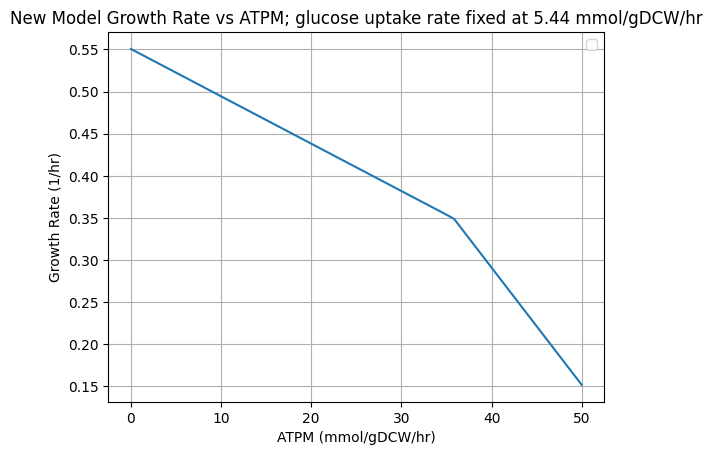

In [154]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
with model:
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates.append(growth_rate)

plt.plot(ATPM_space, growth_rates)
plt.title("New Model Growth Rate vs ATPM; glucose uptake rate fixed at 5.44 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()

100%|██████████| 100/100 [00:02<00:00, 36.90it/s]


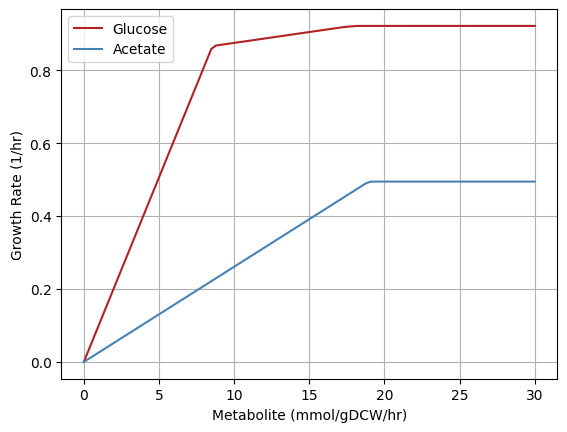

In [155]:
glucose_and_acetate_space = np.linspace(0,30,100)
glucose_growth_rates = []
acetate_growth_rates = []
with model:
    for level in tqdm(glucose_and_acetate_space):
        model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-level, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        glucose_growth_rates.append(growth_rate)
        
        model.reactions.get_by_id("EX_ac").bounds = (-level, 0)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        acetate_growth_rates.append(growth_rate)
        
plt.plot(glucose_and_acetate_space, glucose_growth_rates, label="Glucose",color="firebrick")
plt.plot(glucose_and_acetate_space, acetate_growth_rates, label="Acetate", color="steelblue")
plt.xlabel("Metabolite (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()

In [159]:
# Check knockout of METHYLENETHFDEHYDROG-NADP-RXN effect on growth
ftl = model.reactions.get_by_id("FORMATETHFLIG-RXN")
print(f"Reaction: {ftl.reaction}")
print(f"Bounds:   {ftl.bounds}")
print(f"Flux:     {fluxes_glc[ftl.id]:.4f}")

# The physiological direction is: ATP + formate + THF → ADP + formyl-THF + Pi
# If flux is negative, it's running in reverse (producing ATP)
# Fix: make it irreversible in the forward (ATP-consuming) direction
print(f"\nCurrent lower bound: {ftl.lower_bound}")
print("If lower_bound < 0, the reaction can run in reverse and produce ATP")
print("Consider setting: ftl.lower_bound = 0")

# Test the impact
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    sol = model.optimize()
    old_growth_rate_glucose = sol.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    old_growth_rate_acetate = sol_ac.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()

    sol_fixed = model.optimize()
    print(f"\nGrowth with METHYLENETHFDEHYDROG-NADP-RXN knockout: {sol_fixed.objective_value:.4f}")
    print(f"Growth before fix:                          {old_growth_rate_glucose}")
    
    # Also check acetate isn't affected
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac_fixed = model.optimize()
    print(f"\nAcetate growth with fix:    {sol_ac_fixed.objective_value:.4f}")
    print(f"Acetate growth without fix: {old_growth_rate_acetate:.4f}")

Reaction: ATP[c] + FORMATE[c] + THF-GLU-N[c] <=> ADP[c] + FORMYL-THF-GLU-N[c] + Pi[c]
Bounds:   (-1000.0, 1000.0)
Flux:     -5.2283

Current lower bound: -1000.0
If lower_bound < 0, the reaction can run in reverse and produce ATP
Consider setting: ftl.lower_bound = 0

Growth with METHYLENETHFDEHYDROG-NADP-RXN knockout: 0.5507
Growth before fix:                          0.5686917382526502

Acetate growth with fix:    0.3918
Acetate growth without fix: 0.3952


In [162]:
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    # Block FORMATETHFLIG-RXN reverse
    model.reactions.get_by_id("FORMATETHFLIG-RXN").lower_bound = 0
    sol = model.optimize()
    fluxes_fixed = sol.fluxes
    
    print("=== FLUX CHANGES AFTER BLOCKING FORMATETHFLIG-RXN REVERSE ===\n")
    
    # What changed?
    changes = []
    for rxn_id in fluxes_glc.index:
        old = fluxes_glc[rxn_id]
        new = fluxes_fixed[rxn_id]
        if abs(old - new) > 0.1:
            changes.append((rxn_id, old, new, new - old))
    
    changes_df = pd.DataFrame(changes, columns=["rxn_id", "old_flux", "new_flux", "delta"])
    changes_df["abs_delta"] = changes_df["delta"].abs()
    changes_df = changes_df.sort_values("abs_delta", ascending=False)
    
    for _, row in changes_df.iterrows():
        rxn = model.reactions.get_by_id(row["rxn_id"])
        print(f"  {row['rxn_id']:45s}  {row['old_flux']:+8.3f} → {row['new_flux']:+8.3f}  Δ={row['delta']:+8.3f}")
        print(f"    {rxn.reaction}")
    
    # Check: is formate now being handled differently?
    print("\n=== FORMATE BALANCE AFTER FIX ===")
    for m in model.metabolites:
        if "FORMATE" in m.id:
            for rxn in m.reactions:
                f = fluxes_fixed[rxn.id]
                if abs(f) > 0.01:
                    coeff = rxn.metabolites[m]
                    print(f"  {rxn.id:40s}  coeff={coeff:+.1f}  flux={f:8.3f}")
    
    # Check ATP producers after fix
    print("\n=== TOP ATP PRODUCERS AFTER FIX ===")
    atp_prod = []
    for rxn in model.reactions:
        flux = fluxes_fixed[rxn.id]
        if abs(flux) < 1e-6:
            continue
        for met, coeff in rxn.metabolites.items():
            if "ATP[c]" == met.id:
                rate = coeff * flux
                if rate > 0.1:
                    atp_prod.append((rxn.id, flux, rate))
    
    atp_df = pd.DataFrame(atp_prod, columns=["rxn_id", "flux", "atp_produced"])
    atp_df = atp_df.sort_values("atp_produced", ascending=False)
    print(atp_df.to_string(index=False))
    print(f"\nTotal ATP produced: {atp_df['atp_produced'].sum():.2f}")

=== FLUX CHANGES AFTER BLOCKING FORMATETHFLIG-RXN REVERSE ===

  Htex                                            +83.616 →  +77.147  Δ=  -6.470
    PROTON[e] <=> PROTON[p]
  1.2.1.2-RXN                                      +5.473 →   +0.238  Δ=  -5.235
    FORMATE[c] + NAD[c] --> CARBON-DIOXIDE[c] + NADH[c]
  METHENYLTHFCYCLOHYDRO-RXN                        +5.463 →   +0.229  Δ=  -5.234
    5-10-METHENYL-THF-GLU-N[c] + WATER[c] <=> FORMYL-THF-GLU-N[c] + PROTON[c]
  METHYLENETHFDEHYDROG-NADP-RXN                    +5.463 →   +0.229  Δ=  -5.234
    METHYLENE-THF-GLU-N[c] + NADP[c] <=> 5-10-METHENYL-THF-GLU-N[c] + NADPH[c]
  FORMATETHFLIG-RXN                                -5.228 →   +0.000  Δ=  +5.228
    ATP[c] + FORMATE[c] + THF-GLU-N[c] --> ADP[c] + FORMYL-THF-GLU-N[c] + Pi[c]
  1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.    -5.143 →   +0.000  Δ=  +5.143
    L-ASPARTATE[c] + NADP[c] + WATER[c] <=> AMMONIUM[c] + NADPH[c] + OXALACETIC_ACID[c] + PROTON[

RXN0-300 is not in biocyc. neither is GLYCERATE-DEHYDROGENASE-RXN. neither is 1.4.1.21-RXN





100%|██████████| 100/100 [00:00<00:00, 133.99it/s]
/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_47182/479688821.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


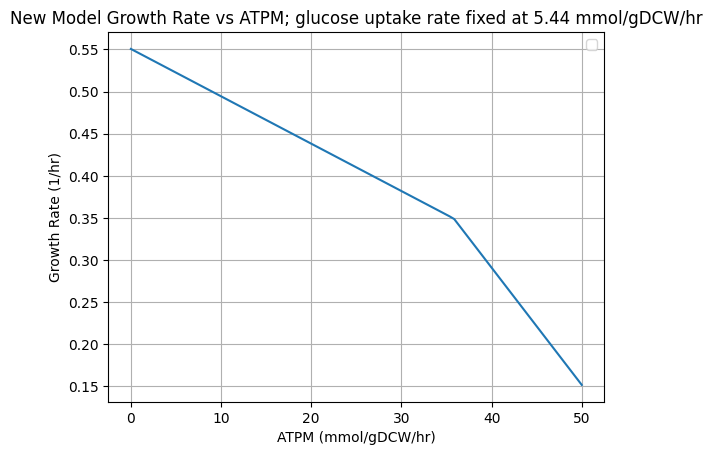

In [164]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
with model:
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
        model.reactions.get_by_id("RXN0-300").knock_out()
        model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
        model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates.append(growth_rate)

plt.plot(ATPM_space, growth_rates)
plt.title("New Model Growth Rate vs ATPM; glucose uptake rate fixed at 5.44 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()

In [165]:
# Check knockout of METHYLENETHFDEHYDROG-NADP-RXN effect on growth
ftl = model.reactions.get_by_id("FORMATETHFLIG-RXN")
print(f"Reaction: {ftl.reaction}")
print(f"Bounds:   {ftl.bounds}")
print(f"Flux:     {fluxes_glc[ftl.id]:.4f}")

# The physiological direction is: ATP + formate + THF → ADP + formyl-THF + Pi
# If flux is negative, it's running in reverse (producing ATP)
# Fix: make it irreversible in the forward (ATP-consuming) direction
print(f"\nCurrent lower bound: {ftl.lower_bound}")
print("If lower_bound < 0, the reaction can run in reverse and produce ATP")
print("Consider setting: ftl.lower_bound = 0")

# Test the impact
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    sol = model.optimize()
    old_growth_rate_glucose = sol.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    old_growth_rate_acetate = sol_ac.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()

    sol_fixed = model.optimize()
    print(f"\nGrowth with METHYLENETHFDEHYDROG-NADP-RXN knockout: {sol_fixed.objective_value:.4f}")
    print(f"Growth before fix:                          {old_growth_rate_glucose}")
    
    # Also check acetate isn't affected
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac_fixed = model.optimize()
    print(f"\nAcetate growth with fix:    {sol_ac_fixed.objective_value:.4f}")
    print(f"Acetate growth without fix: {old_growth_rate_acetate:.4f}")

Reaction: ATP[c] + FORMATE[c] + THF-GLU-N[c] <=> ADP[c] + FORMYL-THF-GLU-N[c] + Pi[c]
Bounds:   (-1000.0, 1000.0)
Flux:     -5.2283

Current lower bound: -1000.0
If lower_bound < 0, the reaction can run in reverse and produce ATP
Consider setting: ftl.lower_bound = 0

Growth with METHYLENETHFDEHYDROG-NADP-RXN knockout: 0.5507
Growth before fix:                          0.5686917382526644

Acetate growth with fix:    0.3918
Acetate growth without fix: 0.3952


In [167]:
model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").reaction

'L-ASPARTATE[c] + NAD[c] + WATER[c] <=> AMMONIUM[c] + NADH[c] + OXALACETIC_ACID[c] + PROTON[c]'

In [166]:
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    #knockouts 
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    
    sol = model.optimize()
    fluxes_fixed = sol.fluxes
    
    print("=== FLUX CHANGES AFTER knockouts ===\n")
    
    
    # What changed?
    changes = []
    for rxn_id in fluxes_glc.index:
        old = fluxes_glc[rxn_id]
        new = fluxes_fixed[rxn_id]
        if abs(old - new) > 0.1:
            changes.append((rxn_id, old, new, new - old))
    
    changes_df = pd.DataFrame(changes, columns=["rxn_id", "old_flux", "new_flux", "delta"])
    changes_df["abs_delta"] = changes_df["delta"].abs()
    changes_df = changes_df.sort_values("abs_delta", ascending=False)
    
    for _, row in changes_df.iterrows():
        rxn = model.reactions.get_by_id(row["rxn_id"])
        print(f"  {row['rxn_id']:45s}  {row['old_flux']:+8.3f} → {row['new_flux']:+8.3f}  Δ={row['delta']:+8.3f}")
        print(f"    {rxn.reaction}")
    
    # Check: is formate now being handled differently?
    print("\n=== FORMATE BALANCE AFTER FIX ===")
    for m in model.metabolites:
        if "FORMATE" in m.id:
            for rxn in m.reactions:
                f = fluxes_fixed[rxn.id]
                if abs(f) > 0.01:
                    coeff = rxn.metabolites[m]
                    print(f"  {rxn.id:40s}  coeff={coeff:+.1f}  flux={f:8.3f}")
    
    # Check ATP producers after fix
    print("\n=== TOP ATP PRODUCERS AFTER FIX ===")
    atp_prod = []
    for rxn in model.reactions:
        flux = fluxes_fixed[rxn.id]
        if abs(flux) < 1e-6:
            continue
        for met, coeff in rxn.metabolites.items():
            if "ATP[c]" == met.id:
                rate = coeff * flux
                if rate > 0.1:
                    atp_prod.append((rxn.id, flux, rate))
    
    atp_df = pd.DataFrame(atp_prod, columns=["rxn_id", "flux", "atp_produced"])
    atp_df = atp_df.sort_values("atp_produced", ascending=False)
    print(atp_df.to_string(index=False))
    print(f"\nTotal ATP produced: {atp_df['atp_produced'].sum():.2f}")

=== FLUX CHANGES AFTER knockouts ===

  Htex                                            +83.616 →  +76.597  Δ=  -7.019
    PROTON[e] <=> PROTON[p]
  1.2.1.2-RXN                                      +5.473 →   +0.009  Δ=  -5.464
    FORMATE[c] + NAD[c] --> CARBON-DIOXIDE[c] + NADH[c]
  METHYLENETHFDEHYDROG-NADP-RXN                    +5.463 →   +0.000  Δ=  -5.463
    METHYLENE-THF-GLU-N[c] + NADP[c] --> 5-10-METHENYL-THF-GLU-N[c] + NADPH[c]
  METHENYLTHFCYCLOHYDRO-RXN                        +5.463 →   +0.000  Δ=  -5.463
    5-10-METHENYL-THF-GLU-N[c] + WATER[c] <=> FORMYL-THF-GLU-N[c] + PROTON[c]
  FORMATETHFLIG-RXN                                -5.228 →   +0.228  Δ=  +5.456
    ATP[c] + FORMATE[c] + THF-GLU-N[c] <=> ADP[c] + FORMYL-THF-GLU-N[c] + Pi[c]
  1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.    -5.143 →   +0.000  Δ=  +5.143
    L-ASPARTATE[c] + NADP[c] + WATER[c] <=> AMMONIUM[c] + NADPH[c] + OXALACETIC_ACID[c] + PROTON[c]
  RXN-11662           

In [168]:
# Find all potential NADPH↔NADH transhydrogenase pairs
from collections import defaultdict

# Group reactions by their non-cofactor metabolites
def get_core_metabolites(rxn):
    """Get metabolites excluding NAD(P)(H), H2O, H+"""
    cofactors = {"NAD[c]", "NADH[c]", "NADP[c]", "NADPH[c]", 
                 "WATER[c]", "PROTON[c]"}
    return frozenset((m.id, coeff) for m, coeff in rxn.metabolites.items() 
                     if m.id not in cofactors)

def uses_nadph(rxn):
    return any(m.id in ("NADPH[c]", "NADP[c]") for m in rxn.metabolites)

def uses_nadh(rxn):
    return any(m.id in ("NADH[c]", "NAD[c]") for m in rxn.metabolites)

# Find pairs that have same core metabolites but different cofactors
core_groups = defaultdict(list)
for rxn in model.reactions:
    core = get_core_metabolites(rxn)
    if core and (uses_nadph(rxn) or uses_nadh(rxn)):
        core_groups[core].append(rxn)

print("=== POTENTIAL TRANSHYDROGENASE PAIRS ===")
print("(Same core reaction, different NAD(P)(H) cofactor)\n")
pairs = []
for core, rxns in core_groups.items():
    nadph_rxns = [r for r in rxns if uses_nadph(r)]
    nadh_rxns = [r for r in rxns if uses_nadh(r)]
    if nadph_rxns and nadh_rxns:
        for nr in nadph_rxns:
            for nh in nadh_rxns:
                pairs.append((nr, nh))
                print(f"  NADPH: {nr.id:50s}  bounds={nr.bounds}")
                print(f"    {nr.reaction}")
                print(f"  NADH:  {nh.id:50s}  bounds={nh.bounds}")
                print(f"    {nh.reaction}")
                print()

print(f"Total pairs found: {len(pairs)}")
print("\nTo fix: for each pair, either remove one reaction,")
print("make both irreversible in the same direction,")
print("or use loopless FBA to prevent simultaneous operation.")

=== POTENTIAL TRANSHYDROGENASE PAIRS ===
(Same core reaction, different NAD(P)(H) cofactor)

  NADPH: MALIC-NADP-RXN                                      bounds=(0.0, 1000.0)
    MAL[c] + NADP[c] --> CARBON-DIOXIDE[c] + NADPH[c] + PYRUVATE[c]
  NADH:  1.1.1.39-RXN                                        bounds=(0.0, 1000.0)
    MAL[c] + NAD[c] --> CARBON-DIOXIDE[c] + NADH[c] + PYRUVATE[c]

  NADPH: GLYC3PDEHYDROGBIOSYN-RXN-GLYCEROL-3P/NADP//DIHYDROXY-ACETONE-PHOSPHATE/NADPH/PROTON.59.  bounds=(0.0, 1000.0)
    DIHYDROXY-ACETONE-PHOSPHATE[c] + NADPH[c] + PROTON[c] --> GLYCEROL-3P[c] + NADP[c]
  NADH:  1.1.1.8-RXN                                         bounds=(0.0, 1000.0)
    DIHYDROXY-ACETONE-PHOSPHATE[c] + NADH[c] + PROTON[c] --> GLYCEROL-3P[c] + NAD[c]

  NADPH: 1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.  bounds=(-1000.0, 1000.0)
    L-ASPARTATE[c] + NADP[c] + WATER[c] <=> AMMONIUM[c] + NADPH[c] + OXALACETIC_ACID[c] + PROTON[c]
  NADH:  1.4.1.21-RX

In [169]:
m = model.metabolites.get_by_id("DIHYDROXY-ACETONE-PHOSPHATE[c]")
print(m.id, m.name, m.formula)

DIHYDROXY-ACETONE-PHOSPHATE[c] glycerone phosphate C3H5O6P


1.4.1.21 not in reaction list 
NADH-KINASE-RXN not in reaction list
R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.

remove:
- 1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.
- 1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.
- NADH-KINASE-RXN 
- R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.
- R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.
- RXN0-3962 
- RXN_1.14.99.60_NADPH    
- RXN_1.14.99.60_NADH 

In [171]:

# The physiological direction is: ATP + formate + THF → ADP + formyl-THF + Pi
# If flux is negative, it's running in reverse (producing ATP)
# Fix: make it irreversible in the forward (ATP-consuming) direction
print(f"\nCurrent lower bound: {ftl.lower_bound}")
print("If lower_bound < 0, the reaction can run in reverse and produce ATP")
print("Consider setting: ftl.lower_bound = 0")

# Test the impact
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    sol = model.optimize()
    old_growth_rate_glucose = sol.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    old_growth_rate_acetate = sol_ac.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()

    sol_fixed = model.optimize()
    print(f"\nGrowth with METHYLENETHFDEHYDROG-NADP-RXN knockout: {sol_fixed.objective_value:.4f}")
    print(f"Growth before fix:                          {old_growth_rate_glucose}")
    
    # Also check acetate isn't affected
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac_fixed = model.optimize()
    print(f"\nAcetate growth with fix:    {sol_ac_fixed.objective_value:.4f}")
    print(f"Acetate growth without fix: {old_growth_rate_acetate:.4f}")


Current lower bound: -1000.0
If lower_bound < 0, the reaction can run in reverse and produce ATP
Consider setting: ftl.lower_bound = 0

Growth with METHYLENETHFDEHYDROG-NADP-RXN knockout: 0.5507
Growth before fix:                          0.5686917382527072

Acetate growth with fix:    0.3918
Acetate growth without fix: 0.3952


In [172]:
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    #knockouts 
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()
    
    sol = model.optimize()
    fluxes_fixed = sol.fluxes
    
    print("=== FLUX CHANGES AFTER knockouts ===\n")
    
    
    # What changed?
    changes = []
    for rxn_id in fluxes_glc.index:
        old = fluxes_glc[rxn_id]
        new = fluxes_fixed[rxn_id]
        if abs(old - new) > 0.1:
            changes.append((rxn_id, old, new, new - old))
    
    changes_df = pd.DataFrame(changes, columns=["rxn_id", "old_flux", "new_flux", "delta"])
    changes_df["abs_delta"] = changes_df["delta"].abs()
    changes_df = changes_df.sort_values("abs_delta", ascending=False)
    
    for _, row in changes_df.iterrows():
        rxn = model.reactions.get_by_id(row["rxn_id"])
        print(f"  {row['rxn_id']:45s}  {row['old_flux']:+8.3f} → {row['new_flux']:+8.3f}  Δ={row['delta']:+8.3f}")
        print(f"    {rxn.reaction}")
    
    # Check: is formate now being handled differently?
    print("\n=== FORMATE BALANCE AFTER FIX ===")
    for m in model.metabolites:
        if "FORMATE" in m.id:
            for rxn in m.reactions:
                f = fluxes_fixed[rxn.id]
                if abs(f) > 0.01:
                    coeff = rxn.metabolites[m]
                    print(f"  {rxn.id:40s}  coeff={coeff:+.1f}  flux={f:8.3f}")
    
    # Check ATP producers after fix
    print("\n=== TOP ATP PRODUCERS AFTER FIX ===")
    atp_prod = []
    for rxn in model.reactions:
        flux = fluxes_fixed[rxn.id]
        if abs(flux) < 1e-6:
            continue
        for met, coeff in rxn.metabolites.items():
            if "ATP[c]" == met.id:
                rate = coeff * flux
                if rate > 0.1:
                    atp_prod.append((rxn.id, flux, rate))
    
    atp_df = pd.DataFrame(atp_prod, columns=["rxn_id", "flux", "atp_produced"])
    atp_df = atp_df.sort_values("atp_produced", ascending=False)
    print(atp_df.to_string(index=False))
    print(f"\nTotal ATP produced: {atp_df['atp_produced'].sum():.2f}")

=== FLUX CHANGES AFTER knockouts ===

  ASPARTASE-RXN                                    -1.091 →   -9.533  Δ=  -8.443
    L-ASPARTATE[c] <=> AMMONIUM[c] + FUM[c]
  Htex                                            +83.616 →  +76.597  Δ=  -7.019
    PROTON[e] <=> PROTON[p]
  GLUTAMATE-DEHYDROGENASE-RXN                      +0.000 →   +5.998  Δ=  +5.998
    GLT[c] + NAD[c] + WATER[c] --> 2-KETOGLUTARATE[c] + AMMONIUM[c] + NADH[c] + PROTON[c]
  1.2.1.2-RXN                                      +5.473 →   +0.009  Δ=  -5.464
    FORMATE[c] + NAD[c] --> CARBON-DIOXIDE[c] + NADH[c]
  METHYLENETHFDEHYDROG-NADP-RXN                    +5.463 →   +0.000  Δ=  -5.463
    METHYLENE-THF-GLU-N[c] + NADP[c] --> 5-10-METHENYL-THF-GLU-N[c] + NADPH[c]
  METHENYLTHFCYCLOHYDRO-RXN                        +5.463 →   +0.000  Δ=  -5.463
    5-10-METHENYL-THF-GLU-N[c] + WATER[c] <=> FORMYL-THF-GLU-N[c] + PROTON[c]
  FORMATETHFLIG-RXN                                -5.228 →   +0.228  Δ=  +5.456
    ATP[c] + FORMATE

In [173]:
with model:
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    
    #knockouts 
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()
    
    sol = model.optimize()
    fluxes_fixed = sol.fluxes
    
    print("=== FLUX CHANGES AFTER knockouts ===\n")
    
    
    # What changed?
    changes = []
    for rxn_id in fluxes_glc.index:
        old = fluxes_glc[rxn_id]
        new = fluxes_fixed[rxn_id]
        if abs(old - new) > 0.1:
            changes.append((rxn_id, old, new, new - old))
    
    changes_df = pd.DataFrame(changes, columns=["rxn_id", "old_flux", "new_flux", "delta"])
    changes_df["abs_delta"] = changes_df["delta"].abs()
    changes_df = changes_df.sort_values("abs_delta", ascending=False)
    
    for _, row in changes_df.iterrows():
        rxn = model.reactions.get_by_id(row["rxn_id"])
        print(f"  {row['rxn_id']:45s}  {row['old_flux']:+8.3f} → {row['new_flux']:+8.3f}  Δ={row['delta']:+8.3f}")
        print(f"    {rxn.reaction}")
    
    # Check: is formate now being handled differently?
    print("\n=== FORMATE BALANCE AFTER FIX ===")
    for m in model.metabolites:
        if "FORMATE" in m.id:
            for rxn in m.reactions:
                f = fluxes_fixed[rxn.id]
                if abs(f) > 0.01:
                    coeff = rxn.metabolites[m]
                    print(f"  {rxn.id:40s}  coeff={coeff:+.1f}  flux={f:8.3f}")
    
    # Check ATP producers after fix
    print("\n=== TOP ATP PRODUCERS AFTER FIX ===")
    atp_prod = []
    for rxn in model.reactions:
        flux = fluxes_fixed[rxn.id]
        if abs(flux) < 1e-6:
            continue
        for met, coeff in rxn.metabolites.items():
            if "ATP[c]" == met.id:
                rate = coeff * flux
                if rate > 0.1:
                    atp_prod.append((rxn.id, flux, rate))
    
    atp_df = pd.DataFrame(atp_prod, columns=["rxn_id", "flux", "atp_produced"])
    atp_df = atp_df.sort_values("atp_produced", ascending=False)
    print(atp_df.to_string(index=False))
    print(f"\nTotal ATP produced: {atp_df['atp_produced'].sum():.2f}")

=== FLUX CHANGES AFTER knockouts ===

  Htex                                            +83.616 →  +60.395  Δ= -23.221
    PROTON[e] <=> PROTON[p]
  ASPARTASE-RXN                                    -1.091 →  -19.401  Δ= -18.310
    L-ASPARTATE[c] <=> AMMONIUM[c] + FUM[c]
  PEPCARBOXYKIN-RXN                                +0.244 →  +17.207  Δ= +16.964
    ATP[c] + OXALACETIC_ACID[c] --> ADP[c] + CARBON-DIOXIDE[c] + PHOSPHO-ENOL-PYRUVATE[c]
  GLUTAMATE-DEHYDROGENASE-RXN                      +0.000 →  +16.886  Δ= +16.886
    GLT[c] + NAD[c] + WATER[c] --> 2-KETOGLUTARATE[c] + AMMONIUM[c] + NADH[c] + PROTON[c]
  EX_h                                             +4.113 →  -12.174  Δ= -16.286
    PROTON[e] <=> 
  Ktpp                                             +0.111 →  -14.931  Δ= -15.042
    K+[p] <=> K+[c]
  ACtex                                            +0.000 →  +15.010  Δ= +15.010
    ACET[e] <=> ACET[p]
  EX_ac                                            +0.000 →  -15.010  Δ= -15.010

=== TOP ATP PRODUCERS AFTER FIX === GLUCOSE
                             rxn_id       flux  atp_produced
                         ATPSYN-RXN -31.661071     31.661071
                    PHOSGLYPHOS-RXN  -4.975706      4.975706
                     SUCCCOASYN-RXN  -3.605912      3.605912
                      PEPDEPHOS-RXN   2.589606      2.589606
PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN  -1.337650      1.337650
             MALATE--COA-LIGASE-RXN  -0.768995      0.768995
                     ADENYL-KIN-RXN  -0.216468      0.216468

=== TOP ATP PRODUCERS AFTER FIX === ACETATE
                             rxn_id       flux  atp_produced
                         ATPSYN-RXN -30.797982     30.797982
PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN -15.961707     15.961707
                     SUCCCOASYN-RXN  -9.834654      9.834654
             MALATE--COA-LIGASE-RXN  -9.150842      9.150842
                     ADENYL-KIN-RXN  -0.154012      0.154012

In [174]:
from cobra.flux_analysis.loopless import loopless_solution

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    # Only apply biologically justified knockout
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    sol_glc = loopless_solution(model)

with model:
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    sol_ac = loopless_solution(model)

print(f"Loopless glucose: {sol_glc.objective_value:.4f}")
print(f"Loopless acetate: {sol_ac.objective_value:.4f}")

Loopless glucose: 0.5507
Loopless acetate: 0.3918


In [175]:
from cobra.flux_analysis import pfba

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    sol_glc = pfba(model)
    print(f"pFBA glucose: {sol_glc.objective_value:.4f}")
    
    # Check the transhydrogenase pairs
    print("\nKey cycle fluxes (glucose):")
    for rid in ["1.5.1.8-RXN", "1.5.1.7-RXN", "MALATE-DEHYDROGENASE-NADP+-RXN", 
                "MALATE-DEH-RXN", "RXN-5901", "RXN-11662",
                "FORMATETHFLIG-RXN", "GCVMULTI-RXN"]:
        try:
            print(f"  {rid:50s}: {sol_glc.fluxes[rid]:+8.4f}")
        except KeyError:
            pass

with model:
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    sol_ac = pfba(model)
    print(f"\npFBA acetate: {sol_ac.objective_value:.4f}")
    
    print("\nKey cycle fluxes (acetate):")
    for rid in ["1.5.1.8-RXN", "1.5.1.7-RXN", "MALATE-DEHYDROGENASE-NADP+-RXN",
                "MALATE-DEH-RXN", "RXN-5901", "RXN-11662",
                "FORMATETHFLIG-RXN", "GCVMULTI-RXN"]:
        try:
            print(f"  {rid:50s}: {sol_ac.fluxes[rid]:+8.4f}")
        except KeyError:
            pass

print(f"\nGlc/Ac ratio: {sol_glc.objective_value / sol_ac.objective_value:.2f}")

pFBA glucose: 485.5789

Key cycle fluxes (glucose):
  1.5.1.8-RXN                                       :  +0.0000
  1.5.1.7-RXN                                       :  +0.0000
  MALATE-DEHYDROGENASE-NADP+-RXN                    :  +0.0000
  MALATE-DEH-RXN                                    :  +0.7690
  RXN-5901                                          :  -1.2814
  RXN-11662                                         :  +0.0000
  FORMATETHFLIG-RXN                                 :  +0.2277
  GCVMULTI-RXN                                      :  +0.0000

pFBA acetate: 693.9710

Key cycle fluxes (acetate):
  1.5.1.8-RXN                                       :  +0.0000
  1.5.1.7-RXN                                       :  +0.0000
  MALATE-DEHYDROGENASE-NADP+-RXN                    : +16.9582
  MALATE-DEH-RXN                                    :  +0.0000
  RXN-5901                                          :  -6.6697
  RXN-11662                                         :  -2.8457
  FORMATETHFL

from cobra.flux_analysis.loopless import loopless_solution

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    # Only apply biologically justified knockout
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    sol_glc = loopless_solution(model)

with model:
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    sol_ac = loopless_solution(model)

print(f"Loopless glucose: {sol_glc.objective_value:.4f}")
print(f"Loopless acetate: {sol_ac.objective_value:.4f}")

pFBA glucose: 485.5789

Key cycle fluxes (glucose):
  1.5.1.8-RXN                                       :  +0.0000
  1.5.1.7-RXN                                       :  +0.0000
  MALATE-DEHYDROGENASE-NADP+-RXN                    :  +0.0000
  MALATE-DEH-RXN                                    :  +1.5255
  RXN-5901                                          :  -1.2814
  RXN-11662                                         :  +0.0000
  FORMATETHFLIG-RXN                                 :  +0.2277
  GCVMULTI-RXN                                      :  +0.0000

pFBA acetate: 693.9710

Key cycle fluxes (acetate):
  1.5.1.8-RXN                                       :  +0.0000
  1.5.1.7-RXN                                       :  +0.0000
  MALATE-DEHYDROGENASE-NADP+-RXN                    : +16.9582
  MALATE-DEH-RXN                                    :  +0.0000
  RXN-5901                                          :  -6.6697
  RXN-11662                                         :  -2.8457
  FORMATETHFL

SIGMA

In [186]:

# The physiological direction is: ATP + formate + THF → ADP + formyl-THF + Pi
# If flux is negative, it's running in reverse (producing ATP)
# Fix: make it irreversible in the forward (ATP-consuming) direction
print(f"\nCurrent lower bound: {ftl.lower_bound}")
print("If lower_bound < 0, the reaction can run in reverse and produce ATP")
print("Consider setting: ftl.lower_bound = 0")

# Test the impact
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    sol = model.optimize()
    old_growth_rate_glucose = sol.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    old_growth_rate_acetate = sol_ac.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()

    sol_fixed = model.optimize()
    print(f"\nGrowth with knockouts: {sol_fixed.objective_value:.4f}")
    print(f"Growth before fix:                          {old_growth_rate_glucose:.4f}")
    
    # Also check acetate isn't affected
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac_fixed = model.optimize()
    print(f"\nAcetate growth with fix:    {sol_ac_fixed.objective_value:.4f}")
    print(f"Acetate growth without fix: {old_growth_rate_acetate:.4f}")


Current lower bound: -1000.0
If lower_bound < 0, the reaction can run in reverse and produce ATP
Consider setting: ftl.lower_bound = 0

Growth with knockouts: 0.5507
Growth before fix:                          0.5687

Acetate growth with fix:    0.3918
Acetate growth without fix: 0.3952


In [189]:
model.reactions.get_by_id("Rpom_hwa_biomass").reaction

'31.36179486 ATP[c] + 0.001524574 COFACTORS[c] + 0.05136379 DNA[c] + 0.009825009 IONS[c] + 0.095950926 LIPID[c] + 0.026355529 MUREIN[c] + 0.000447 NADP[c] + 0.001831 NAD[c] + 0.091372857 PHB-STORAGE[c] + 0.561521914 PROTEIN[c] + 0.093597842 RNA[c] + 48.601527 WATER[c] --> 31.36179573 ADP[c] + 31.36179573 PROTON[c] + 31.35745773 Pi[c]'

In [192]:
get_metabolite_reactions("LIPID[c]")

Consuming reactions:
	Rpom_hwa_biomass: 31.36179486 ATP[c] + 0.001524574 COFACTORS[c] + 0.05136379 DNA[c] + 0.009825009 IONS[c] + 0.095950926 LIPID[c] + 0.026355529 MUREIN[c] + 0.000447 NADP[c] + 0.001831 NAD[c] + 0.091372857 PHB-STORAGE[c] + 0.561521914 PROTEIN[c] + 0.093597842 RNA[c] + 48.601527 WATER[c] --> 31.36179573 ADP[c] + 31.36179573 PROTON[c] + 31.35745773 Pi[c]
Producing reactions:
	LIPID-RXN: 0.186220192 CPD-12819[c] + 0.478848946 CPD-12819[p] + 0.564392674 CPD-17086[c] + 0.219487198 CPD-17086[p] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]



([<Reaction Rpom_hwa_biomass at 0x1281ddc70>],
 [<Reaction LIPID-RXN at 0x1281ddc10>])

In [194]:
get_metabolite_reactions("CPD-12817[c]")

Consuming reactions:
	PHOSPHASERDECARB-RXN-2: CPD-12817[c] + PROTON[c] --> CARBON-DIOXIDE[c] + CPD-12819[c]
Producing reactions:
	PHOSPHASERSYN-RXN-2: SER[c] + cdpdhdecg[c] --> CMP[c] + CPD-12817[c] + PROTON[c]



([<Reaction PHOSPHASERDECARB-RXN-2 at 0x11e382b80>],
 [<Reaction PHOSPHASERSYN-RXN-2 at 0x11e382910>])

In [196]:
get_metabolite_reactions("CPD-17086[c]")
get_metabolite_reactions("L-1-PHOSPHATIDYL-SERINE[c]")

Consuming reactions:
	LIPID-RXN: 0.186220192 CPD-12819[c] + 0.478848946 CPD-12819[p] + 0.564392674 CPD-17086[c] + 0.219487198 CPD-17086[p] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]
	3.6.3.1-RXN: ATP[c] + CPD-17086[c] + WATER[c] --> ADP[c] + CPD-17086[p] + PROTON[c] + Pi[c]
Producing reactions:
	PHOSPHASERDECARB-RXN: L-1-PHOSPHATIDYL-SERINE[c] + PROTON[c] --> CARBON-DIOXIDE[c] + CPD-17086[c]

Consuming reactions:
	PHOSPHASERDECARB-RXN: L-1-PHOSPHATIDYL-SERINE[c] + PROTON[c] --> CARBON-DIOXIDE[c] + CPD-17086[c]
Producing reactions:
	PHOSPHASERSYN-RXN: CDPDIACYLGLYCEROL[c] + SER[c] --> CMP[c] + L-1-PHOSPHATIDYL-SERINE[c] + PROTON[c]



([<Reaction PHOSPHASERDECARB-RXN at 0x11e3829a0>],
 [<Reaction PHOSPHASERSYN-RXN at 0x11e366c10>])

In [256]:
m = model.metabolites.get_by_id("CPD-12819[c]")
print(m.reactions, m.id, m.name, m.formula)

frozenset({<Reaction 3.6.3.1-RXN-2 at 0x16dd2d580>, <Reaction PHOSPHASERDECARB-RXN-2 at 0x16dfb3fd0>, <Reaction LIPID-RXN at 0x12afa3070>}) CPD-12819[c] [] C37H74N1O8P1


# THE ISSUE IS SERINE PRODUCTION WHICH GIVES CPD-12817, THEN CPD-12819 WHICH OVERDRIVES THE LIPID REACTION AND THEREFORE THE BIOMASS REACTION!!!
# also via L-1-PHOSPHATIDYL-SERINE[c] generation from SERINE, which gives CPD-17086 which also feeds into the LIPID reaction

## Next steps: figure out more appropriate lipids to model the system?

In [225]:
m  = model.metabolites.get_by_id("SER[c]")
get_metabolite_reactions("SER[c]")
print(m.reactions, m.id, m.name, m.formula)

Consuming reactions:
	PHOSPHASERSYN-RXN: CDPDIACYLGLYCEROL[c] + SER[c] --> CMP[c] + L-1-PHOSPHATIDYL-SERINE[c] + PROTON[c]
	SERINE-O-ACETTRAN-RXN: ACETYL-COA[c] + SER[c] --> ACETYLSERINE[c] + CO-A[c]
	RXN0-2382: INDOLE[c] + SER[c] --> TRP[c] + WATER[c]
	PHOSPHASERSYN-RXN-2: SER[c] + cdpdhdecg[c] --> CMP[c] + CPD-12817[c] + PROTON[c]
	SERINE--GLYOXYLATE-AMINOTRANSFERASE-RXN: GLYOX[c] + SER[c] <=> GLY[c] + OH-PYR[c]
	RXN-15125: SER[c] --> 2-AMINOACRYLATE[c] + WATER[c]
	CYSTATHIONINE-BETA-SYNTHASE-RXN: HOMO-CYS[c] + SER[c] <=> L-CYSTATHIONINE[c] + WATER[c]
	4.3.1.17-RXN: SER[c] --> AMMONIUM[c] + PYRUVATE[c]
	PROTEIN-RXN: 0.437725018 ARG[c] + 0.356722982 ASN[c] + 33.1963969 ATP[c] + 0.135523805 CYS[c] + 0.389434859 GLN[c] + 0.389434859 GLT[c] + 0.906606601 GLY[c] + 0.140197141 HIS[c] + 0.429936617 ILE[c] + 0.760177851 L-ALPHA-ALANINE[c] + 0.356722982 L-ASPARTATE[c] + 0.666714077 LEU[c] + 0.507823589 LYS[c] + 0.227430786 MET[c] + 0.274162674 PHE[c] + 0.32712617 PRO[c] + 0.319337768 SER[c] +

In [226]:
rxn_id ="RXN0-5114"
my_rxn = model.reactions.get_by_id(rxn_id)
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    sol = model.optimize()
    print(f"Growth rate: {sol.objective_value:.4f} 1/hr")
    baseline_flux = sol.fluxes[my_rxn.id]
    print(f"Flux through {my_rxn.id}: {baseline_flux}")

Growth rate: 0.5687 1/hr
Flux through RXN0-5114: 3.463280753677635


In [227]:
rxn_id ="RXN0-5114"
my_rxn = model.reactions.get_by_id(rxn_id)
with model:
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol = model.optimize()
    print(f"Growth rate: {sol.objective_value:.4f} 1/hr")
    baseline_flux = sol.fluxes[my_rxn.id]
    print(f"Flux through {my_rxn.id}: {baseline_flux}")

Growth rate: 0.3952 1/hr
Flux through RXN0-5114: 1.0202688484561289


In [255]:
big = 3.463280753677673
base = 1.02026884845615
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol = model.optimize()
    old_growth_rate_glucose = sol.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    old_growth_rate_acetate = sol_ac.objective_value
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)    
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    """
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()
    """
    
    # add a source reaction for Serine 

    model.reactions.get_by_id("RXN0-5114").knock_out()
    #model.reactions.get_by_id("RXN-14136").knock_out()
    #model.reactions.get_by_id("SERINE--GLYOXYLATE-AMINOTRANSFERASE-RXN").knock_out()
    #model.reactions.get_by_id("CYSTATHIONINE-BETA-SYNTHASE-RXN").knock_out()
    #model.reactions.get_by_id("GLYOHMETRANS-RXN").knock_out()
    serine_source = model.add_boundary(
        model.metabolites.get_by_id("SER[c]"),
        type="source",
        reaction_id="SER[c]_source",
        ub=0,  # Set to exactly the lost flux from above!
        lb=-base
    )
    
    p_serine_sink = model.add_boundary(
        model.metabolites.get_by_id("3-P-SERINE[c]"),
        type="sink",
        reaction_id="3-P-SERINE[c]_sink",
        lb=big,
        ub=big
    )
    
    water_sink = model.add_boundary(
        model.metabolites.get_by_id("WATER[c]"),
        type="sink",
        reaction_id="WATER[c]_sink",
        lb=base,
        ub=base
    )

    sol_fixed = model.optimize() 
    """
    my_rxn = model.reactions.get_by_id("SER[c]_source")
    baseline_flux = sol_fixed.fluxes[my_rxn.id]
    print(f"Flux through {my_rxn.id}: {baseline_flux}")
    """
    
    print(f"\nGrowth with knockouts: {sol_fixed.objective_value:.4f}")
    print(f"Growth before fix:     {old_growth_rate_glucose:.4f}")
    
    # Also check acetate isn't affected
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac_fixed = model.optimize()
    print(f"\nAcetate growth with fix:    {sol_ac_fixed.objective_value:.4f}")
    print(f"Acetate growth without fix: {old_growth_rate_acetate:.4f}")
    


Growth with knockouts: 0.4272
Growth before fix:     0.5687

Acetate growth with fix:    0.2565
Acetate growth without fix: 0.3952


3.463280753677673 - 1.02026884845615

Trying some things

In [272]:
# Check what CDP-diacylglycerol species exist in the model
for m in model.metabolites:
    if "CDP" in m.id and ("diacyl" in m.name.lower() or "CDPDIACYL" in m.id.upper()):
        print(f"{m.id}: {m.name}  {m.formula}")
        print("  Producing reactions:")
        for rxn in m.reactions:
            coeff = rxn.metabolites[m]
            if coeff > 0:
                print(f"    {rxn.id}: {rxn.reaction}")
        print("  Consuming reactions:")
        for rxn in m.reactions:
            coeff = rxn.metabolites[m]
            if coeff < 0:
                print(f"    {rxn.id}: {rxn.reaction}")
        print()

# Check for glycerol-3-phosphate
for m in model.metabolites:
    if "glycerol" in m.name.lower() and "phospha" in m.name.lower() and "[c]" in m.id:
        print(f"{m.id}: {m.name}  {m.formula}")
        
# Check for CMP
for m in model.metabolites:
    if m.id == "CMP[c]":
        print(f"{m.id}: {m.name}  {m.formula}")

# Check CPDQT-520
cpdqt = model.metabolites.get_by_id("CPDQT-520[c]")
print(f"\n{cpdqt.id}: {cpdqt.name}  {cpdqt.formula}")
print("All reactions:")
for rxn in cpdqt.reactions:
    coeff = rxn.metabolites[cpdqt]
    print(f"  {rxn.id} (coeff={coeff:+.1f}): {rxn.reaction}")


CDPDIACYLGLYCEROL[c]: a CDP-diacylglycerol  C44H75N3O15P2
  Producing reactions:
    CDPDIGLYSYN-RXN: CTP[c] + L-PHOSPHATIDATE[c] + PROTON[c] --> CDPDIACYLGLYCEROL[c] + PPI[c]
  Consuming reactions:
    PHOSPHASERSYN-RXN: CDPDIACYLGLYCEROL[c] + SER[c] --> CMP[c] + L-1-PHOSPHATIDYL-SERINE[c] + PROTON[c]
    PHOSPHAGLYPSYN-RXN: CDPDIACYLGLYCEROL[c] + GLYCEROL-3P[c] --> CMP[c] + L-1-PHOSPHATIDYL-GLYCEROL-P[c] + PROTON[c]

ACYL-SN-GLYCEROL-3P[c]: a 1-acyl-sn-glycerol 3-phosphate  C19H35O7P
L-PHOSPHATIDATE[c]: a 1,2-diacyl-sn-glycerol 3-phosphate  C35H63O8P
GLYCEROL-3P[c]: sn-glycerol 3-phosphate  C3H7O6P
D-ERYTHRO-IMIDAZOLE-GLYCEROL-P[c]: D-erythro-imidazole-glycerol-phosphate  C6H9N2O6P
INDOLE-3-GLYCEROL-P[c]: (1S,2R)-1-C-(indol-3-yl)glycerol 3-phosphate  C11H12NO6P
L-1-PHOSPHATIDYL-GLYCEROL-P[c]: 1-(3-sn-phosphatidyl)-sn-glycerol 3-phosphate  C38H69O13P2
1-PALMITOYLGLYCEROL-3-PHOSPHATE[c]: 1-palmitoyl-sn-glycerol 3-phosphate  C19H37O7P
CPD-2183[c]: 1-oleoyl-2-palmitoyl-phosphatidylglycer

In [293]:
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    # === 1. Fix RXN-13313 ===
    #model.remove_reactions([model.reactions.get_by_id("RXN-13313")])
    model.reactions.get_by_id("RXN-13313").knock_out()
    
    generic_pg = cobra.Metabolite(
        "GENERIC-PG[c]",
        formula="C38H68O10P",
        name="a phosphatidylglycerol (generic)",
        compartment="c"
    )
    
    L1PGP = model.metabolites.get_by_id("L-1-PHOSPHATIDYL-GLYCEROL-P[c]")
    WATER = model.metabolites.get_by_id("WATER[c]")
    Pi = model.metabolites.get_by_id("Pi[c]")
    PROTON = model.metabolites.get_by_id("PROTON[c]")
    
    rxn_pgpp = cobra.Reaction("RXN-13313_v2")
    rxn_pgpp.name = "Phosphatidylglycerophosphatase"
    rxn_pgpp.bounds = (0, 1000.0)
    rxn_pgpp.add_metabolites({
        L1PGP:      -1,
        WATER:      -1,
        generic_pg:  1,
        Pi:          1,
        PROTON:      1
    })
    model.add_reactions([rxn_pgpp])
    
    # === 2. Test PG production ===
    sol = model.optimize()
    print(f"Max generic PG demand (with glucose): {sol.objective_value:.4f}")
    
    if sol.objective_value > 1e-6:
        model.reactions.get_by_id("LIPID-RXN").knock_out()
        #model.remove_reactions([model.reactions.get_by_id("DM_GENERIC-PG[c]")])
        
        pe_sat_c = model.metabolites.get_by_id("CPD-12819[c]")
        pe_sat_p = model.metabolites.get_by_id("CPD-12819[p]")
        pe_unsat_c = model.metabolites.get_by_id("CPD-17086[c]")
        pe_unsat_p = model.metabolites.get_by_id("CPD-17086[p]")
        undec = model.metabolites.get_by_id("UNDECAPRENYL-DIPHOSPHATE[c]")
        lipid_met = model.metabolites.get_by_id("LIPID[c]")
        
        total = 1.449
        pe_frac = 0.30 * total
        pg_frac = 0.70 * total
        scale = pe_frac / total
        
        lipid_rxn_new = cobra.Reaction("LIPID-RX_v2")
        lipid_rxn_new.name = "Lipid pseudoreaction (PG-dominant, Stirrup 2022)"
        lipid_rxn_new.bounds = (0, 1000.0)
        lipid_rxn_new.add_metabolites({
            #pe_sat_c:   -(0.186 * scale),
            #pe_sat_p:   -(0.479 * scale),
            #pe_unsat_c: -(0.564 * scale),
            #pe_unsat_p: -(0.220 * scale),
            generic_pg: -pg_frac,
            undec:      -0.000573,
            lipid_met:   1.0
        })
        model.add_reactions([lipid_rxn_new])
        print(f"\nNew LIPID-RXN: {lipid_rxn_new.reaction}")
        
        # Test glucose growth
        model.objective = "Rpom_hwa_biomass"
        model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
        sol_glc = model.optimize()
        print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
        print(f"PHOSPHAGLYPSYN-RXN: {sol_glc.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
        print(f"CDPDIGLYSYN-RXN: {sol_glc.fluxes['CDPDIGLYSYN-RXN']:.4f}")
        print(f"PHOSPHASERSYN-RXN: {sol_glc.fluxes['PHOSPHASERSYN-RXN']:.4f}")
        
        # Test acetate growth
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        model.reactions.get_by_id("EX_ac").bounds = (-10, 0)
        sol_ac = model.optimize()
        print(f"\nAcetate growth:  {sol_ac.objective_value:.4f}")
        print(f"Ratio: {sol_glc.objective_value / sol_ac.objective_value:.2f}")
    else:
        print("\nPG still blocked - debugging:")
        model.objective = "Rpom_hwa_biomass"
        sol_grow = model.optimize()
        print(f"Growth (original LIPID-RXN): {sol_grow.objective_value:.4f}")
        print(f"CDPDIGLYSYN-RXN: {sol_grow.fluxes['CDPDIGLYSYN-RXN']:.4f}")
        print(f"PHOSPHAGLYPSYN-RXN: {sol_grow.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
        
        # Force PHOSPHAGLYPSYN and check
        model.reactions.get_by_id("PHOSPHAGLYPSYN-RXN").lower_bound = 0.001
        sol_force = model.optimize()
        print(f"\nForced PHOSPHAGLYPSYN: status={sol_force.status}, growth={sol_force.objective_value:.4f}")

Max generic PG demand (with glucose): 0.5687

New LIPID-RXN: 1.0143 GENERIC-PG[c] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]

Glucose growth: 0.5733
PHOSPHAGLYPSYN-RXN: 0.0558
CDPDIGLYSYN-RXN: 0.0558
PHOSPHASERSYN-RXN: 0.0000

Acetate growth:  0.2716
Ratio: 2.11


In [292]:
search_metabolites(["glutamine"])

id                     | name                                    | formula   
-----------------------+-----------------------------------------+-----------
GLN[c]                 | L-glutamine                             | C5H10N2O3 
FORMYL-ISOGLUTAMINE[c] | formyl-L-isoglutamine                   | C6H9N2O4  
ISOGLUTAMINE[c]        | L-isoglutamine                          | C5H10N2O3 
GLN[p]                 | L-glutamine                             | C5H10N2O3 
GLN[e]                 | L-glutamine                             | C5H10N2O3 
CPD-22333[c]           | &beta;-citryl-L-glutamine               | C11H13N2O9
GLUTAMIDE[c]           | D-glutamine                             | C5H10N2O3 
N5-METHYLGLUTAMINE[c]  | <i>N</i><sup>5</sup>-methyl-L-glutamine | C6H12N2O3 


In [294]:
# Check for ornithine, glutamine, glutamate, beta-hydroxy fatty acids
for name_search in ["ornithine", "glutamine", "glutamate"]:
    print(f"\n=== {name_search} ===")
    for m in model.metabolites:
        if name_search.lower() in m.name.lower() and "[c]" in m.id:
            print(f"  {m.id}: {m.name}  {m.formula}")

# Check for acyl-ACP and beta-hydroxy acyl intermediates
print("\n=== Fatty acid / acyl-ACP / beta-hydroxy ===")
for m in model.metabolites:
    if "[c]" in m.id and ("hydroxy" in m.name.lower() and "acyl" in m.name.lower()):
        print(f"  {m.id}: {m.name}  {m.formula}")

# Also check for 3-hydroxyacyl-ACP from fatty acid synthesis
print("\n=== 3-hydroxy acyl-ACP ===")
for m in model.metabolites:
    if "[c]" in m.id and "3-hydroxy" in m.name.lower() and "acp" in m.id.upper():
        print(f"  {m.id}: {m.name}  {m.formula}")

# Check for palmitoyl/oleoyl-ACP
print("\n=== Long-chain acyl-ACP ===")
for m in model.metabolites:
    if "[c]" in m.id and "ACP" in m.id and m.id not in ["ACP[c]"]:
        print(f"  {m.id}: {m.name}  {m.formula}")

# Check for beta-hydroxy fatty acyl-CoA
print("\n=== 3-hydroxy acyl-CoA ===")
for m in model.metabolites:
    if "[c]" in m.id and "hydroxy" in m.name.lower() and ("CoA" in m.name or "COA" in m.id or "co-a" in m.name.lower()):
        print(f"  {m.id}: {m.name}  {m.formula}")

# Check existing OlsA/OlsB related reactions
print("\n=== Existing OL/QL reactions ===")
for r in model.reactions:
    if "ols" in r.id.lower() or "gls" in r.id.lower() or "ornithine" in r.name.lower():
        print(f"  {r.id}: {r.name}  |  {r.reaction}")


=== ornithine ===
  L-ORNITHINE[c]: L-ornithine  C5H13N2O2
  N-ALPHA-ACETYLORNITHINE[c]: N-acetyl-L-ornithine  C7H14N2O3
  CPD-217[c]: D-ornithine  C5H13N2O2

=== glutamine ===
  GLN[c]: L-glutamine  C5H10N2O3
  FORMYL-ISOGLUTAMINE[c]: formyl-L-isoglutamine  C6H9N2O4
  ISOGLUTAMINE[c]: L-isoglutamine  C5H10N2O3
  CPD-22333[c]: &beta;-citryl-L-glutamine  C11H13N2O9
  GLUTAMIDE[c]: D-glutamine  C5H10N2O3
  N5-METHYLGLUTAMINE[c]: <i>N</i><sup>5</sup>-methyl-L-glutamine  C6H12N2O3

=== glutamate ===
  GLT[c]: L-glutamate  C5H8NO4
  ACETYL-GLU[c]: N-acetyl-L-glutamate  C7H9NO5
  CPD-469[c]: N-acetyl-L-glutamate 5-semialdehyde  C7H10NO4
  D-GLT[c]: D-glutamate  C5H8NO4
  DIHYDROFOLATE[c]: 7,8-dihydrofolate monoglutamate  C19H19N7O6
  CPD-600[c]: N-formyl-L-glutamate  C6H7NO5
  N-FORMIMINO-L-GLUTAMATE[c]: N-formimino-L-glutamate  C6H9N2O4
  L-GLUTAMATE_GAMMA-SEMIALDEHYDE[c]: L-glutamate-5-semialdehyde  C5H9NO3
  UDP-AA-GLUTAMATE[c]: UDP-N-acetyl-alpha-D-muramoyl-L-alanyl-D-glutamate  C28H39N

In [ ]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
growth_rates_ac = []

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    # key knockouts 
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()
    
    # === Get existing metabolites ===
    orn = model.metabolites.get_by_id("L-ORNITHINE[c]")
    gln = model.metabolites.get_by_id("GLN[c]")
    ACP = model.metabolites.get_by_id("ACP[c]")
    WATER = model.metabolites.get_by_id("WATER[c]")
    Pi = model.metabolites.get_by_id("Pi[c]")
    PROTON = model.metabolites.get_by_id("PROTON[c]")
    
    # 3-hydroxy-palmitoyl-ACP (beta-hydroxy C16:0 donor for OlsB/GlsB)
    oh_palm_acp = model.metabolites.get_by_id("R-3-Hydroxypalmitoyl-ACPs[c]")
    # Palmitoyl-ACP (second acyl donor for OlsA)
    palm_acp = model.metabolites.get_by_id("Palmitoyl-ACPs[c]")
    
    print(f"3-OH-palmitoyl-ACP: {oh_palm_acp.id}, {oh_palm_acp.formula}")  # C16H31O2X
    print(f"Palmitoyl-ACP: {palm_acp.id}, {palm_acp.formula}")              # C16H31OX
    print(f"ACP: {ACP.id}, {ACP.formula}")
    print(f"Ornithine: {orn.id}, {orn.formula}")   # C5H13N2O2
    print(f"Glutamine: {gln.id}, {gln.formula}")    # C5H10N2O3
    
    # === Create new metabolites ===
    # Lyso-OL: ornithine + 3-OH-C16:0 linked via amide bond (loses H2O)
    # = C5H13N2O2 + C16H31O2(ACP) - H2O - ACP = C21H42N2O3
    # But ACP has formula X, so: ornithine + 3-OH-palm - ACP - H2O
    # C5H13N2O2 + C16H31O2X - X - H2O = C21H42N2O3
    lyso_OL = cobra.Metabolite(
        "LYSO-OL[c]",
        formula="C21H42N2O3",
        name="lyso-ornithine lipid",
        compartment="c"
    )
    
    # OL: lyso-OL + palmitoyl (O-ester bond, loses H2O... but from ACP)
    # lyso-OL has a free hydroxyl on the beta-hydroxy FA; OlsA esterifies it
    # C21H42N2O3 + C16H31OX - X - (bond formation) 
    # Acyl transfer from ACP: lyso-OL + palm-ACP -> OL + ACP
    # C21H42N2O3 + C16H31O(X) -> C37H71N2O3(+O from ester) + X
    # OL = C37H71N2O4  (ester linkage adds one O)
    OL = cobra.Metabolite(
        "OL-LIPID[c]",
        formula="C37H71N2O4",
        name="ornithine lipid",
        compartment="c"
    )
    
    # Lyso-QL: glutamine + 3-OH-C16:0 linked via amide bond
    # C5H10N2O3 + C16H31O2X - X - H2O = C21H39N2O4
    lyso_QL = cobra.Metabolite(
        "LYSO-QL[c]",
        formula="C21H39N2O4",
        name="lyso-glutamine lipid",
        compartment="c"
    )
    
    # QL: lyso-QL + palmitoyl
    # C21H39N2O4 + C16H31OX - X = C37H68N2O5
    QL = cobra.Metabolite(
        "QL-LIPID[c]",
        formula="C37H68N2O5",
        name="glutamine lipid",
        compartment="c"
    )
    
    # === Create reactions ===
    
    # 1. OlsB: L-ornithine + 3-OH-palmitoyl-ACP -> lyso-OL + ACP + H2O
    rxn_olsB = cobra.Reaction("OLSB-RXN")
    rxn_olsB.name = "OlsB N-acyltransferase (ornithine lipid)"
    rxn_olsB.bounds = (0, 1000.0)
    rxn_olsB.add_metabolites({
        orn:          -1,
        oh_palm_acp:  -1,
        lyso_OL:       1,
        ACP:           1,
        WATER:         1,
    })
    
    # 2. OlsA (for OL): lyso-OL + palmitoyl-ACP -> OL + ACP
    rxn_olsA_OL = cobra.Reaction("OLSA-RXN-OL")
    rxn_olsA_OL.name = "OlsA O-acyltransferase (ornithine lipid)"
    rxn_olsA_OL.bounds = (0, 1000.0)
    rxn_olsA_OL.add_metabolites({
        lyso_OL:   -1,
        palm_acp:  -1,
        OL:         1,
        ACP:        1,
    })
    
    # 3. GlsB: L-glutamine + 3-OH-palmitoyl-ACP -> lyso-QL + ACP + H2O
    rxn_glsB = cobra.Reaction("GLSB-RXN")
    rxn_glsB.name = "GlsB N-acyltransferase (glutamine lipid)"
    rxn_glsB.bounds = (0, 1000.0)
    rxn_glsB.add_metabolites({
        gln:          -1,
        oh_palm_acp:  -1,
        lyso_QL:       1,
        ACP:           1,
        WATER:         1,
    })
    
    # 4. OlsA (for QL): lyso-QL + palmitoyl-ACP -> QL + ACP
    rxn_olsA_QL = cobra.Reaction("OLSA-RXN-QL")
    rxn_olsA_QL.name = "OlsA O-acyltransferase (glutamine lipid)"
    rxn_olsA_QL.bounds = (0, 1000.0)
    rxn_olsA_QL.add_metabolites({
        lyso_QL:   -1,
        palm_acp:  -1,
        QL:         1,
        ACP:        1,
    })
    
    model.add_reactions([rxn_olsB, rxn_olsA_OL, rxn_glsB, rxn_olsA_QL])
    
    # Check mass balances
    for rxn in [rxn_olsB, rxn_olsA_OL, rxn_glsB, rxn_olsA_QL]:
        bal = rxn.check_mass_balance()
        print(f"{rxn.id}: {rxn.reaction}")
        print(f"  Mass balance: {bal}")
    
    # === Fix PG pathway (from before) ===
    model.reactions.get_by_id("RXN-13313").knock_out()
    
    generic_pg = cobra.Metabolite(
        "GENERIC-PG[c]",
        formula="C38H68O10P",
        name="a phosphatidylglycerol (generic)",
        compartment="c"
    )
    L1PGP = model.metabolites.get_by_id("L-1-PHOSPHATIDYL-GLYCEROL-P[c]")
    
    rxn_pgpp = cobra.Reaction("RXN-13313_2")
    rxn_pgpp.name = "Phosphatidylglycerophosphatase"
    rxn_pgpp.bounds = (0, 1000.0)
    rxn_pgpp.add_metabolites({
        L1PGP: -1, WATER: -1, generic_pg: 1, Pi: 1, PROTON: 1
    })
    model.add_reactions([rxn_pgpp])
    
    # === New LIPID-RXN: ~40% PG, ~20% PE, ~20% OL, ~20% QL ===
    # Based on Stirrup 2022: PG dominant, OL+QL significant, PE secondary
    model.reactions.get_by_id("LIPID-RXN").knock_out()
    
    pe_sat_c = model.metabolites.get_by_id("CPD-12819[c]")
    pe_sat_p = model.metabolites.get_by_id("CPD-12819[p]")
    pe_unsat_c = model.metabolites.get_by_id("CPD-17086[c]")
    pe_unsat_p = model.metabolites.get_by_id("CPD-17086[p]")
    undec = model.metabolites.get_by_id("UNDECAPRENYL-DIPHOSPHATE[c]")
    lipid_met = model.metabolites.get_by_id("LIPID[c]")
    
    total = 1.449  # keep total lipid demand same
    pg_frac  = 0.60 * total  # 0.580
    pe_frac  = 0.20 * total  # 0.290
    ol_frac  = 0.10 * total  # 0.290
    ql_frac  = 0.10 * total  # 0.290
    pe_scale = pe_frac / total
    
    lipid_rxn_new = cobra.Reaction("LIPID-RXN_2")
    lipid_rxn_new.name = "Lipid pseudoreaction (PG/PE/OL/QL, Stirrup 2022)"
    lipid_rxn_new.bounds = (0, 1000.0)
    lipid_rxn_new.add_metabolites({
        pe_sat_c:   -(0.186 * pe_scale), # grams of lipid per mmol of whatever metabolite
        pe_sat_p:   -(0.479 * pe_scale),
        pe_unsat_c: -(0.564 * pe_scale),
        pe_unsat_p: -(0.220 * pe_scale),
        generic_pg: -pg_frac,
        OL:         -ol_frac,
        QL:         -ql_frac,
        undec:      -0.000573,
        lipid_met:   1.0
    })
    model.add_reactions([lipid_rxn_new])
    
    print(f"\nNew LIPID-RXN: {lipid_rxn_new.reaction}")
    print(f"  PG: {pg_frac:.3f}, PE: {pe_frac:.3f}, OL: {ol_frac:.3f}, QL: {ql_frac:.3f}")
    
    # === Test growth ===
    model.objective = "Rpom_hwa_biomass"
    
    sol_glc = model.optimize()
    print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
    print(f"  PHOSPHAGLYPSYN-RXN: {sol_glc.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
    print(f"  PHOSPHASERSYN-RXN: {sol_glc.fluxes['PHOSPHASERSYN-RXN']:.4f}")
    print(f"  OLSB-RXN: {sol_glc.fluxes['OLSB-RXN']:.4f}")
    print(f"  GLSB-RXN: {sol_glc.fluxes['GLSB-RXN']:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"\nAcetate growth:  {sol_ac.objective_value:.4f}")
    print(f"  PHOSPHAGLYPSYN-RXN: {sol_ac.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
    print(f"  PHOSPHASERSYN-RXN: {sol_ac.fluxes['PHOSPHASERSYN-RXN']:.4f}")
    print(f"  OLSB-RXN: {sol_ac.fluxes['OLSB-RXN']:.4f}")
    print(f"  GLSB-RXN: {sol_ac.fluxes['GLSB-RXN']:.4f}")
    
    print(f"\nRatio (glc/ac): {sol_glc.objective_value / sol_ac.objective_value:.2f}")
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates.append(growth_rate)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates_ac.append(growth_rate)

3-OH-palmitoyl-ACP: R-3-Hydroxypalmitoyl-ACPs[c], C16H31O2X
Palmitoyl-ACP: Palmitoyl-ACPs[c], C16H31OX
ACP: ACP[c], XH
Ornithine: L-ORNITHINE[c], C5H13N2O2
Glutamine: GLN[c], C5H10N2O3
OLSB-RXN: L-ORNITHINE[c] + R-3-Hydroxypalmitoyl-ACPs[c] --> ACP[c] + LYSO-OL[c] + WATER[c]
  Mass balance: {'H': 1, 'charge': -1}
OLSA-RXN-OL: LYSO-OL[c] + Palmitoyl-ACPs[c] --> ACP[c] + OL-LIPID[c]
  Mass balance: {'H': -1}
GLSB-RXN: GLN[c] + R-3-Hydroxypalmitoyl-ACPs[c] --> ACP[c] + LYSO-QL[c] + WATER[c]
  Mass balance: {'H': 1}
OLSA-RXN-QL: LYSO-QL[c] + Palmitoyl-ACPs[c] --> ACP[c] + QL-LIPID[c]
  Mass balance: {'H': -1}

New LIPID-RXN: 0.0372 CPD-12819[c] + 0.09579999999999998 CPD-12819[p] + 0.11279999999999998 CPD-17086[c] + 0.044 CPD-17086[p] + 0.8694000000000001 GENERIC-PG[c] + 0.1449 OL-LIPID[c] + 0.1449 QL-LIPID[c] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]
  PG: 0.869, PE: 0.290, OL: 0.145, QL: 0.145

Glucose growth: 0.5505
  PHOSPHAGLYPSYN-RXN: 0.0459
  PHOSPHASERSYN-RXN: 0.0083


KeyError: 'OLSB-RXN_EC_2.3.2.30'

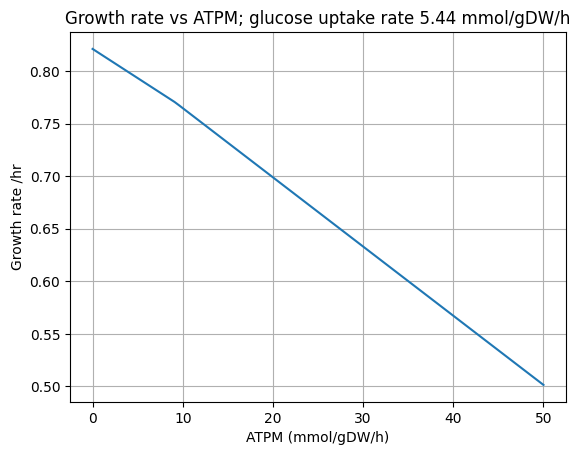

In [13]:
plt.plot(ATPM_space, growth_rates)
plt.xlabel("ATPM (mmol/gDW/h)")
plt.ylabel("Growth rate /hr")
plt.title("Growth rate vs ATPM; glucose uptake rate 5.44 mmol/gDW/h")
plt.grid(True)
plt.show()


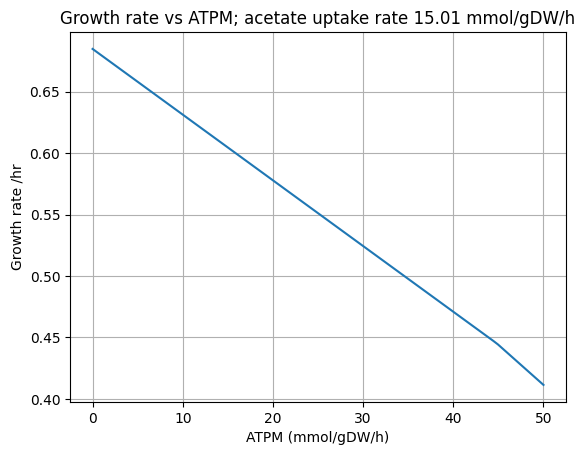

In [14]:
plt.plot(ATPM_space, growth_rates_ac)
plt.xlabel("ATPM (mmol/gDW/h)")
plt.ylabel("Growth rate /hr")
plt.title("Growth rate vs ATPM; acetate uptake rate 15.01 mmol/gDW/h")
plt.grid(True)
plt.show()


so much for my serine-based hypothesis

In [314]:
search_reactions(["Ex_glc"])

id     | name             | reaction              | GPR | LB  | UB    
-------+------------------+-----------------------+-----+-----+-------
EX_glc | Glucose exchange | Glucopyranose[e] -->  |     | 0.0 | 1000.0


In [315]:
search_metabolites(["Glucopyranose[e]"])

id | name | formula
---+------+--------


In [318]:
get_metabolite_reactions("Glucopyranose[e]")

get_metabolite_reactions("Glucopyranose[p]")

Consuming reactions:
	GLCtex: Glucopyranose[e] <=> Glucopyranose[p]
	EX_glc: Glucopyranose[e] --> 
Producing reactions:

Consuming reactions:
	GLCtpp: ATP[c] + Glucopyranose[p] + WATER[c] --> ADP[c] + Glucopyranose[c] + PROTON[c] + Pi[c]
Producing reactions:
	GLCtex: Glucopyranose[e] <=> Glucopyranose[p]



([<Reaction GLCtpp at 0x12825cf10>], [<Reaction GLCtex at 0x12825c5b0>])

In [320]:
print("Check glycolysis pathway - does the model use ED or EMP?")
for r in model.reactions:
    if any(keyword in r.name.lower() for keyword in ["phosphofructokinase", "6-phosphofructo", "pfk"]):
        print(f"{r.id}: {r.name}  |  {r.reaction}")

print("Check for ED pathway enzymes")
for r in model.reactions:
    if any(keyword in r.id.upper() for keyword in ["PGLUCONDEHYDRAT", "KDPGALDOL", "EDD", "EDA", "GLU6PDEHYDROG"]):
        print(f"{r.id}: {r.name}  |  {r.reaction}")

print("Check for key EMP vs ED indicators")
for rid in ["6PFRUCTPHOS-RXN", "PHOSFRUKTO-RXN", "F16ALDOLASE-RXN", 
            "PGLUCONDEHYDRAT-RXN", "KDPGALDOL-RXN", "GLU6PDEHYDROG-RXN"]:
    try:
        r = model.reactions.get_by_id(rid)
        print(f"{r.id}: {r.reaction}")
    except KeyError:
        print(f"{rid}: NOT IN MODEL")

Check glycolysis pathway - does the model use ED or EMP?
Check for ED pathway enzymes
GLU6PDEHYDROG-RXN: GLU6PDEHYDROG-RXN  |  D-glucopyranose-6-phosphate[c] + NADP[c] --> D-6-P-GLUCONO-DELTA-LACTONE[c] + NADPH[c] + PROTON[c]
KDPGALDOL-RXN: KDPGALDOL-RXN  |  2-KETO-3-DEOXY-6-P-GLUCONATE[c] --> GAP[c] + PYRUVATE[c]
PGLUCONDEHYDRAT-RXN: PGLUCONDEHYDRAT-RXN  |  CPD-2961[c] --> 2-KETO-3-DEOXY-6-P-GLUCONATE[c] + WATER[c]
Check for key EMP vs ED indicators
6PFRUCTPHOS-RXN: NOT IN MODEL
PHOSFRUKTO-RXN: NOT IN MODEL
F16ALDOLASE-RXN: FRUCTOSE-16-DIPHOSPHATE[c] <=> DIHYDROXY-ACETONE-PHOSPHATE[c] + GAP[c]
PGLUCONDEHYDRAT-RXN: CPD-2961[c] --> 2-KETO-3-DEOXY-6-P-GLUCONATE[c] + WATER[c]
KDPGALDOL-RXN: 2-KETO-3-DEOXY-6-P-GLUCONATE[c] --> GAP[c] + PYRUVATE[c]
GLU6PDEHYDROG-RXN: D-glucopyranose-6-phosphate[c] + NADP[c] --> D-6-P-GLUCONO-DELTA-LACTONE[c] + NADPH[c] + PROTON[c]


In [8]:
# Check Htex reaction
r = model.reactions.get_by_id("Htex")
print(f"Htex: {r.reaction}  bounds={r.bounds}")

# Check proton exchange
for rxn in model.reactions:
    if "EX_" in rxn.id and "proton" in rxn.name.lower() or "EX_h" in rxn.id.lower():
        print(f"{rxn.id}: {rxn.name}  |  {rxn.reaction}  bounds={rxn.bounds}")

# What's the proton balance across compartments during glucose growth?
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    sol = model.optimize()
    
    # Find all proton transport/exchange reactions
    print("\nProton-related fluxes:")
    for r in model.reactions:
        if sol.fluxes[r.id] != 0:
            mets = [m.id for m in r.metabolites]
            if any("PROTON" in m or "proton" in m.lower() for m in mets):
                if abs(sol.fluxes[r.id]) > 0.1:
                    print(f"  {r.id}: {sol.fluxes[r.id]:.4f}  |  {r.reaction}")

Htex: PROTON[e] <=> PROTON[p]  bounds=(-1000.0, 1000.0)

Proton-related fluxes:
  1.5.5.1-RXN-ETF-Reduced/UBIQUINONE-10//ETF-Oxidized/CPD-9958/PROTON.56.: 0.8515  |  ETF-Reduced[c] + UBIQUINONE-10[c] --> CPD-9958[c] + ETF-Oxidized[c] + PROTON[c]
  1.8.4.8-RXN: 0.1127  |  PAPS[c] + Red-Thioredoxin[c] --> 3-5-ADP[c] + Ox-Thioredoxin[c] + 2.0 PROTON[c] + SO3[c]
  2-ISOPROPYLMALATESYN-RXN: 0.2062  |  2-KETO-ISOVALERATE[c] + ACETYL-COA[c] + WATER[c] --> 3-CARBOXY-3-HYDROXY-ISOCAPROATE[c] + CO-A[c] + PROTON[c]
  2.3.1.180-RXN: 0.1531  |  ACETYL-COA[c] + MALONYL-ACP[c] + PROTON[c] --> Acetoacetyl-ACPs[c] + CARBON-DIOXIDE[c] + CO-A[c]
  3-HYDROXYBUTYRYL-COA-DEHYDROGENASE-RXN: 1.2814  |  ACETOACETYL-COA[c] + NADPH[c] + PROTON[c] --> NADP[c] + S-3-HYDROXYBUTANOYL-COA[c]
  6PGLUCONOLACT-RXN: 5.0668  |  D-6-P-GLUCONO-DELTA-LACTONE[c] + WATER[c] --> CPD-2961[c] + PROTON[c]
  ACETOLACTREDUCTOISOM-RXN: 0.4001  |  2-ACETO-LACTATE[c] + NADPH[c] + PROTON[c] --> CPD-13357[c] + NADP[c]
  ACETOLACTSYN-RXN:

In [7]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
growth_rates_ac = []

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    # key knockouts 
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()
    
    # === Get existing metabolites ===
    orn = model.metabolites.get_by_id("L-ORNITHINE[c]")
    gln = model.metabolites.get_by_id("GLN[c]")
    ACP = model.metabolites.get_by_id("ACP[c]")
    WATER = model.metabolites.get_by_id("WATER[c]")
    Pi = model.metabolites.get_by_id("Pi[c]")
    PROTON = model.metabolites.get_by_id("PROTON[c]")
    
    # 3-hydroxy-palmitoyl-ACP (beta-hydroxy C16:0 donor for OlsB/GlsB)
    oh_palm_acp = model.metabolites.get_by_id("R-3-Hydroxypalmitoyl-ACPs[c]")
    # Palmitoyl-ACP (second acyl donor for OlsA)
    palm_acp = model.metabolites.get_by_id("Palmitoyl-ACPs[c]")
    
    print(f"3-OH-palmitoyl-ACP: {oh_palm_acp.id}, {oh_palm_acp.formula}")  # C16H31O2X
    print(f"Palmitoyl-ACP: {palm_acp.id}, {palm_acp.formula}")              # C16H31OX
    print(f"ACP: {ACP.id}, {ACP.formula}")
    print(f"Ornithine: {orn.id}, {orn.formula}")   # C5H13N2O2
    print(f"Glutamine: {gln.id}, {gln.formula}")    # C5H10N2O3
    
    # === Create new metabolites ===
    # Lyso-OL: ornithine + 3-OH-C16:0 linked via amide bond (loses H2O)
    # = C5H13N2O2 + C16H31O2(ACP) - H2O - ACP = C21H42N2O3
    # But ACP has formula X, so: ornithine + 3-OH-palm - ACP - H2O
    # C5H13N2O2 + C16H31O2X - X - H2O = C21H42N2O3
    lyso_OL = cobra.Metabolite(
        "LYSO-OL[c]",
        formula="C21H42N2O3",
        name="lyso-ornithine lipid",
        compartment="c"
    )
    
    # OL: lyso-OL + palmitoyl (O-ester bond, loses H2O... but from ACP)
    # lyso-OL has a free hydroxyl on the beta-hydroxy FA; OlsA esterifies it
    # C21H42N2O3 + C16H31OX - X - (bond formation) 
    # Acyl transfer from ACP: lyso-OL + palm-ACP -> OL + ACP
    # C21H42N2O3 + C16H31O(X) -> C37H71N2O3(+O from ester) + X
    # OL = C37H71N2O4  (ester linkage adds one O)
    OL = cobra.Metabolite(
        "OL-LIPID[c]",
        formula="C37H71N2O4",
        name="ornithine lipid",
        compartment="c"
    )
    
    # Lyso-QL: glutamine + 3-OH-C16:0 linked via amide bond
    # C5H10N2O3 + C16H31O2X - X - H2O = C21H39N2O4
    lyso_QL = cobra.Metabolite(
        "LYSO-QL[c]",
        formula="C21H39N2O4",
        name="lyso-glutamine lipid",
        compartment="c"
    )
    
    # QL: lyso-QL + palmitoyl
    # C21H39N2O4 + C16H31OX - X = C37H68N2O5
    QL = cobra.Metabolite(
        "QL-LIPID[c]",
        formula="C37H68N2O5",
        name="glutamine lipid",
        compartment="c"
    )
    
    # === Create reactions ===
    
    # 1. OlsB: L-ornithine + 3-OH-palmitoyl-ACP -> lyso-OL + ACP + H2O
    rxn_olsB = cobra.Reaction("OLSB-RXN")
    rxn_olsB.name = "OlsB N-acyltransferase (ornithine lipid)"
    rxn_olsB.bounds = (0, 1000.0)
    rxn_olsB.add_metabolites({
        orn:          -1,
        oh_palm_acp:  -1,
        lyso_OL:       1,
        ACP:           1,
        WATER:         1,
    })
    
    # 2. OlsA (for OL): lyso-OL + palmitoyl-ACP -> OL + ACP
    rxn_olsA_OL = cobra.Reaction("OLSA-RXN-OL")
    rxn_olsA_OL.name = "OlsA O-acyltransferase (ornithine lipid)"
    rxn_olsA_OL.bounds = (0, 1000.0)
    rxn_olsA_OL.add_metabolites({
        lyso_OL:   -1,
        palm_acp:  -1,
        OL:         1,
        ACP:        1,
    })
    
    # 3. GlsB: L-glutamine + 3-OH-palmitoyl-ACP -> lyso-QL + ACP + H2O
    rxn_glsB = cobra.Reaction("GLSB-RXN")
    rxn_glsB.name = "GlsB N-acyltransferase (glutamine lipid)"
    rxn_glsB.bounds = (0, 1000.0)
    rxn_glsB.add_metabolites({
        gln:          -1,
        oh_palm_acp:  -1,
        lyso_QL:       1,
        ACP:           1,
        WATER:         1,
    })
    
    # 4. OlsA (for QL): lyso-QL + palmitoyl-ACP -> QL + ACP
    rxn_olsA_QL = cobra.Reaction("OLSA-RXN-QL")
    rxn_olsA_QL.name = "OlsA O-acyltransferase (glutamine lipid)"
    rxn_olsA_QL.bounds = (0, 1000.0)
    rxn_olsA_QL.add_metabolites({
        lyso_QL:   -1,
        palm_acp:  -1,
        QL:         1,
        ACP:        1,
    })
    
    model.add_reactions([rxn_olsB, rxn_olsA_OL, rxn_glsB, rxn_olsA_QL])
    
    # Check mass balances
    for rxn in [rxn_olsB, rxn_olsA_OL, rxn_glsB, rxn_olsA_QL]:
        bal = rxn.check_mass_balance()
        print(f"{rxn.id}: {rxn.reaction}")
        print(f"  Mass balance: {bal}")
    
    # === Fix PG pathway (from before) ===
    model.reactions.get_by_id("RXN-13313").knock_out()
    
    generic_pg = cobra.Metabolite(
        "GENERIC-PG[c]",
        formula="C38H68O10P",
        name="a phosphatidylglycerol (generic)",
        compartment="c"
    )
    L1PGP = model.metabolites.get_by_id("L-1-PHOSPHATIDYL-GLYCEROL-P[c]")
    
    rxn_pgpp = cobra.Reaction("RXN-13313_2")
    rxn_pgpp.name = "Phosphatidylglycerophosphatase"
    rxn_pgpp.bounds = (0, 1000.0)
    rxn_pgpp.add_metabolites({
        L1PGP: -1, WATER: -1, generic_pg: 1, Pi: 1, PROTON: 1
    })
    model.add_reactions([rxn_pgpp])
    
    # === New LIPID-RXN: ~40% PG, ~20% PE, ~20% OL, ~20% QL ===
    # Based on Stirrup 2022: PG dominant, OL+QL significant, PE secondary
    model.reactions.get_by_id("LIPID-RXN").knock_out()
    
    pe_sat_c = model.metabolites.get_by_id("CPD-12819[c]")
    pe_sat_p = model.metabolites.get_by_id("CPD-12819[p]")
    pe_unsat_c = model.metabolites.get_by_id("CPD-17086[c]")
    pe_unsat_p = model.metabolites.get_by_id("CPD-17086[p]")
    undec = model.metabolites.get_by_id("UNDECAPRENYL-DIPHOSPHATE[c]")
    lipid_met = model.metabolites.get_by_id("LIPID[c]")
    
    total = 1.449  # keep total lipid demand same
    pg_frac  = 0.60 * total  # 0.580
    pe_frac  = 0.20 * total  # 0.290
    ol_frac  = 0.10 * total  # 0.290
    ql_frac  = 0.10 * total  # 0.290
    pe_scale = pe_frac / total
    
    lipid_rxn_new = cobra.Reaction("LIPID-RXN_2")
    lipid_rxn_new.name = "Lipid pseudoreaction (PG/PE/OL/QL, Stirrup 2022)"
    lipid_rxn_new.bounds = (0, 1000.0)
    lipid_rxn_new.add_metabolites({
        pe_sat_c:   -(0.186 * pe_scale),
        pe_sat_p:   -(0.479 * pe_scale),
        pe_unsat_c: -(0.564 * pe_scale),
        pe_unsat_p: -(0.220 * pe_scale),
        generic_pg: -pg_frac,
        OL:         -ol_frac,
        QL:         -ql_frac,
        undec:      -0.000573,
        lipid_met:   1.0
    })
    model.add_reactions([lipid_rxn_new])
    
    print(f"\nNew LIPID-RXN: {lipid_rxn_new.reaction}")
    print(f"  PG: {pg_frac:.3f}, PE: {pe_frac:.3f}, OL: {ol_frac:.3f}, QL: {ql_frac:.3f}")
    
    # === Test growth ===
    model.objective = "Rpom_hwa_biomass"
    
    sol_glc = model.optimize()
    print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
    print(f"  PHOSPHAGLYPSYN-RXN: {sol_glc.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
    print(f"  PHOSPHASERSYN-RXN: {sol_glc.fluxes['PHOSPHASERSYN-RXN']:.4f}")
    print(f"  OLSB-RXN: {sol_glc.fluxes['OLSB-RXN']:.4f}")
    print(f"  GLSB-RXN: {sol_glc.fluxes['GLSB-RXN']:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"\nAcetate growth:  {sol_ac.objective_value:.4f}")
    print(f"  PHOSPHAGLYPSYN-RXN: {sol_ac.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
    print(f"  PHOSPHASERSYN-RXN: {sol_ac.fluxes['PHOSPHASERSYN-RXN']:.4f}")
    print(f"  OLSB-RXN: {sol_ac.fluxes['OLSB-RXN']:.4f}")
    print(f"  GLSB-RXN: {sol_ac.fluxes['GLSB-RXN']:.4f}")
    
    print(f"\nRatio (glc/ac): {sol_glc.objective_value / sol_ac.objective_value:.2f}")
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates.append(growth_rate)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates_ac.append(growth_rate)

3-OH-palmitoyl-ACP: R-3-Hydroxypalmitoyl-ACPs[c], C16H31O2X
Palmitoyl-ACP: Palmitoyl-ACPs[c], C16H31OX
ACP: ACP[c], XH
Ornithine: L-ORNITHINE[c], C5H13N2O2
Glutamine: GLN[c], C5H10N2O3
OLSB-RXN: L-ORNITHINE[c] + R-3-Hydroxypalmitoyl-ACPs[c] --> ACP[c] + LYSO-OL[c] + WATER[c]
  Mass balance: {'H': 1, 'charge': -1}
OLSA-RXN-OL: LYSO-OL[c] + Palmitoyl-ACPs[c] --> ACP[c] + OL-LIPID[c]
  Mass balance: {'H': -1}
GLSB-RXN: GLN[c] + R-3-Hydroxypalmitoyl-ACPs[c] --> ACP[c] + LYSO-QL[c] + WATER[c]
  Mass balance: {'H': 1}
OLSA-RXN-QL: LYSO-QL[c] + Palmitoyl-ACPs[c] --> ACP[c] + QL-LIPID[c]
  Mass balance: {'H': -1}

New LIPID-RXN: 0.0372 CPD-12819[c] + 0.09579999999999998 CPD-12819[p] + 0.11279999999999998 CPD-17086[c] + 0.044 CPD-17086[p] + 0.8694000000000001 GENERIC-PG[c] + 0.1449 OL-LIPID[c] + 0.1449 QL-LIPID[c] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]
  PG: 0.869, PE: 0.290, OL: 0.145, QL: 0.145

Glucose growth: 0.5505
  PHOSPHAGLYPSYN-RXN: 0.0459
  PHOSPHASERSYN-RXN: 0.0083
  OLS

 83%|████████▎ | 83/100 [00:00<00:00, 137.20it/s]/Users/acheron/micromamba/envs/rpom/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
100%|██████████| 100/100 [00:00<00:00, 111.24it/s]


In [331]:
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    
    # Block ALL identified NADPH/NADH cycle pairs
    # Force each pair to only run in one direction
    
    # Pair 1: 3-HYDROXYBUTYRYL-COA-DEHYDROGENASE-RXN / RXN-11662
    # Keep RXN-11662 (NAD-linked, needed for beta-oxidation) but constrain
    # to only run in biosynthetic direction
    model.reactions.get_by_id("3-HYDROXYBUTYRYL-COA-DEHYDROGENASE-RXN").knock_out()
    
    # Pair 2: RXN-11209 / RXN0-6565 (thymine/dihydrothymine)
    model.reactions.get_by_id("RXN-11209").knock_out()
    
    # Pair 3: 1.3.1.2-RXN / DIHYDROURACIL-DEHYDROGENASE-NAD+-RXN (uracil)
    model.reactions.get_by_id("1.3.1.2-RXN").knock_out()
    
    # Pair 4: GLUTAMATESYN-RXN / GLUTAMATE-DEHYDROGENASE-RXN
    # These are both physiologically important - constrain GDH to not run 
    # in the NADH-producing direction at high flux
    # Actually check if GDH is being exploited
    
    # Pair 5: saccharopine cycle (1.5.1.8 / 1.5.1.7)
    try:
        model.reactions.get_by_id("1.5.1.8-RXN").knock_out()
    except:
        pass
    try:
        model.reactions.get_by_id("1.5.1.7-RXN").knock_out()
    except:
        pass
    
    # Previous knockouts from your code
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()
    
    sol = model.optimize()
    print(f"Glucose growth: {sol.objective_value:.4f}")
    
    # Check remaining NADPH balance
    NADPH = model.metabolites.get_by_id("NADPH[c]")
    print("\nNADPH consumers (>0.01):")
    for rxn in NADPH.reactions:
        coeff = rxn.metabolites.get(NADPH, 0)
        flux = sol.fluxes[rxn.id]
        net = coeff * flux
        if net < -0.01:
            print(f"  {rxn.id}: {net:.4f}  (flux={flux:.4f})")
    
    print("\nNADPH producers (>0.01):")
    for rxn in NADPH.reactions:
        coeff = rxn.metabolites.get(NADPH, 0)
        flux = sol.fluxes[rxn.id]
        net = coeff * flux
        if net > 0.01:
            print(f"  {rxn.id}: {net:.4f}  (flux={flux:.4f})")
    
    # Now test acetate
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"\nAcetate growth: {sol_ac.objective_value:.4f}")
    print(f"Ratio: {sol.objective_value / sol_ac.objective_value:.3f}")

Glucose growth: 0.5507

NADPH consumers (>0.01):
  ASPARTATE-SEMIALDEHYDE-DEHYDROGENASE-RXN: -0.7641  (flux=-0.7641)
  THIOREDOXIN-REDUCT-NADPH-RXN: -0.1716  (flux=0.1716)
  RXN-9540: -0.1531  (flux=0.1531)
  RXN-9514: -0.1531  (flux=0.1531)
  RXN-8850: -0.0144  (flux=0.0144)
  ACETOOHBUTREDUCTOISOM-RXN: -0.1329  (flux=0.1329)
  RXN-9542: -0.1531  (flux=-0.1531)
  RXN-8957: -0.7686  (flux=0.7686)
  ACETOLACTREDUCTOISOM-RXN: -0.4001  (flux=0.4001)
  GLYC3PDEHYDROGBIOSYN-RXN-GLYCEROL-3P/NADP//DIHYDROXY-ACETONE-PHOSPHATE/NADPH/PROTON.59.: -0.0766  (flux=0.0766)
  SULFITE-REDUCT-RXN: -0.3380  (flux=0.1127)
  RXN-9528: -0.1531  (flux=0.1531)
  RXN-9532: -0.1531  (flux=0.1531)
  RXN-9536: -0.1531  (flux=0.1531)
  RXN-9518: -0.1531  (flux=0.1531)
  N-ACETYLGLUTPREDUCT-RXN: -0.2365  (flux=0.2365)
  RXN-9524: -0.1531  (flux=0.1531)
  SHIKIMATE-5-DEHYDROGENASE-RXN: -0.1744  (flux=0.1744)
  RXN-5901: -4.1870  (flux=-4.1870)
  RXN-14014-DELTA1-PIPERIDEINE-2-6-DICARBOXYLATE/NADP/WATER//CPD-14443/NA

In [332]:
model.reactions.get_by_id("ISOCITDEH-RXN").reaction

'NADP[c] + THREO-DS-ISO-CITRATE[c] <=> 2-KETOGLUTARATE[c] + CARBON-DIOXIDE[c] + NADPH[c]'

In [335]:
with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    
    sol = model.optimize()
    
    # Check proton balance in each compartment
    H_e = model.metabolites.get_by_id("PROTON[e]")
    H_p = model.metabolites.get_by_id("PROTON[p]")
    H_c = model.metabolites.get_by_id("PROTON[c]")
    
    print("=== PROTON[e] reactions (>0.1 flux) ===")
    for rxn in H_e.reactions:
        coeff = rxn.metabolites.get(H_e, 0)
        flux = sol.fluxes[rxn.id]
        net = coeff * flux
        if abs(net) > 0.1:
            print(f"  {net:+8.4f}  {rxn.id}: {rxn.reaction}")
    
    print("\n=== PROTON[p] reactions (>0.1 flux) ===")
    for rxn in H_p.reactions:
        coeff = rxn.metabolites.get(H_p, 0)
        flux = sol.fluxes[rxn.id]
        net = coeff * flux
        if abs(net) > 0.1:
            print(f"  {net:+8.4f}  {rxn.id}: {rxn.reaction}")
    
    print(f"\n=== Key fluxes ===")
    print(f"Htex (H[e] -> H[p]): {sol.fluxes['Htex']:.4f}")
    print(f"EX_h (H[e] exchange): {sol.fluxes['EX_h']:.4f}")
    print(f"ATPSYN-RXN: {sol.fluxes['ATPSYN-RXN']:.4f}")
    print(f"NADH-DEHYDROG-A-RXN: {sol.fluxes['NADH-DEHYDROG-A-RXN']:.4f}")
    print(f"CYTOCHROME-C-OXIDASE-RXN: {sol.fluxes['CYTOCHROME-C-OXIDASE-RXN']:.4f}")
    print(f"1.10.2.2-RXN: {sol.fluxes['1.10.2.2-RXN']:.4f}")
    
    # Now compare with acetate
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    
    print(f"\n=== Acetate comparison ===")
    print(f"Htex: {sol_ac.fluxes['Htex']:.4f}")
    print(f"EX_h: {sol_ac.fluxes['EX_h']:.4f}")
    print(f"ATPSYN-RXN: {sol_ac.fluxes['ATPSYN-RXN']:.4f}")
    print(f"NADH-DEHYDROG-A-RXN: {sol_ac.fluxes['NADH-DEHYDROG-A-RXN']:.4f}")
    print(f"CYTOCHROME-C-OXIDASE-RXN: {sol_ac.fluxes['CYTOCHROME-C-OXIDASE-RXN']:.4f}")
    print(f"1.10.2.2-RXN: {sol_ac.fluxes['1.10.2.2-RXN']:.4f}")

=== PROTON[e] reactions (>0.1 flux) ===
  +80.5837  NADH-DEHYDROG-A-RXN: NADH[c] + 5.0 PROTON[c] + UBIQUINONE-10[c] <=> CPD-9958[c] + NAD[c] + 4.0 PROTON[e]
   -3.9867  EX_h: PROTON[e] <=> 
  -76.5970  Htex: PROTON[e] <=> PROTON[p]

=== PROTON[p] reactions (>0.1 flux) ===
   +0.1452  RXN-14107: 2.0 Cytochromes-C-Oxidized[p] + Menaquinols[c] --> 2.0 Cytochromes-C-Reduced[p] + Menaquinones[c] + 2.0 PROTON[p]
  +76.5970  Htex: PROTON[e] <=> PROTON[p]
  +49.8945  CYTOCHROME-C-OXIDASE-RXN: 4.0 Cytochromes-C-Reduced[p] + OXYGEN-MOLECULE[c] + 8.0 PROTON[c] --> 4.0 Cytochromes-C-Oxidized[p] + 4.0 PROTON[p] + 2.0 WATER[c]
  -126.6443  ATPSYN-RXN: ATP[c] + 3.0 PROTON[c] + WATER[c] <=> ADP[c] + 4.0 PROTON[p] + Pi[c]

=== Key fluxes ===
Htex (H[e] -> H[p]): 76.5970
EX_h (H[e] exchange): 3.9867
ATPSYN-RXN: -31.6611
NADH-DEHYDROG-A-RXN: 20.1459
CYTOCHROME-C-OXIDASE-RXN: 12.4736
1.10.2.2-RXN: 24.8747

=== Acetate comparison ===
Htex: 60.3947
EX_h: -12.1735
ATPSYN-RXN: -30.7980
NADH-DEHYDROG-A-RXN: 12

In [337]:
rxn_atp = model.reactions.get_by_id("ATPSYN-RXN")
print(f"ATPSYN-RXN: {rxn_atp.reaction}")
for met, coeff in rxn_atp.metabolites.items():
    if "PROTON" in met.id:
        print(f"  {coeff:+.0f} {met.id}")

# The key ratio: how many protons pumped per NADH oxidized?
# Complex I: 4 H+ pumped per NADH
# Complex III (1.10.2.2-RXN): check
rxn_ciii = model.reactions.get_by_id("1.10.2.2-RXN")
print(f"\n1.10.2.2-RXN: {rxn_ciii.reaction}")
for met, coeff in rxn_ciii.metabolites.items():
    if "PROTON" in met.id:
        print(f"  {coeff:+.0f} {met.id}")

# Complex IV:
rxn_civ = model.reactions.get_by_id("CYTOCHROME-C-OXIDASE-RXN")
print(f"\nCYTOCHROME-C-OXIDASE-RXN: {rxn_civ.reaction}")
for met, coeff in rxn_civ.metabolites.items():
    if "PROTON" in met.id:
        print(f"  {coeff:+.0f} {met.id}")

# Total H+ pumped per NADH: Complex I + III + IV
# ATP synthase: H+/ATP ratio
# This determines the P/O ratio

# Also check: is EX_h bounded?
rxn_exh = model.reactions.get_by_id("EX_h")
print(f"\nEX_h: {rxn_exh.reaction}  bounds={rxn_exh.bounds}")
print(f"Htex: bounds={model.reactions.get_by_id('Htex').bounds}")

ATPSYN-RXN: ATP[c] + 3.0 PROTON[c] + WATER[c] <=> ADP[c] + 4.0 PROTON[p] + Pi[c]
  -3 PROTON[c]
  +4 PROTON[p]

1.10.2.2-RXN: CPD-9958[c] + 2.0 Cytochromes-C-Oxidized[p] --> 2.0 Cytochromes-C-Reduced[p] + 2.0 PROTON[c] + UBIQUINONE-10[c]
  +2 PROTON[c]

CYTOCHROME-C-OXIDASE-RXN: 4.0 Cytochromes-C-Reduced[p] + OXYGEN-MOLECULE[c] + 8.0 PROTON[c] --> 4.0 Cytochromes-C-Oxidized[p] + 4.0 PROTON[p] + 2.0 WATER[c]
  -8 PROTON[c]
  +4 PROTON[p]

EX_h: PROTON[e] <=>   bounds=(-1000.0, 1000.0)
Htex: bounds=(-1000.0, 1000.0)


In [338]:
with model:
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    
    # Constrain: no free proton import/export
    model.reactions.get_by_id("EX_h").bounds = (0, 0)
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    print(f"Glucose growth (EX_h=0): {sol_glc.objective_value:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"Acetate growth (EX_h=0): {sol_ac.objective_value:.4f}")
    print(f"Ratio: {sol_glc.objective_value / sol_ac.objective_value:.3f}")
    
    # Also try: what if we fix Complex I to pump to [p] instead of [e]
    # AND close EX_h
    model.reactions.get_by_id("EX_h").bounds = (-1000, 1000)  # reopen
    
    # Fix Complex I
    nadh_dh = model.reactions.get_by_id("NADH-DEHYDROG-A-RXN")
    H_e = model.metabolites.get_by_id("PROTON[e]")
    H_p = model.metabolites.get_by_id("PROTON[p]")
    # Remove 4 H+[e], add 4 H+[p]
    nadh_dh.subtract_metabolites({H_e: 4})
    nadh_dh.add_metabolites({H_p: 4})
    print(f"\nFixed NADH-DEHYDROG: {nadh_dh.reaction}")
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc2 = model.optimize()
    print(f"Glucose growth (CI fixed): {sol_glc2.objective_value:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac2 = model.optimize()
    print(f"Acetate growth (CI fixed): {sol_ac2.objective_value:.4f}")
    print(f"Ratio: {sol_glc2.objective_value / sol_ac2.objective_value:.3f}")

Glucose growth (EX_h=0): 0.4411
Acetate growth (EX_h=0): 0.0000


ZeroDivisionError: float division by zero

In [339]:
with model:
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    
    # Fix Complex I: pump to [p] not [e]
    nadh_dh = model.reactions.get_by_id("NADH-DEHYDROG-A-RXN")
    H_e = model.metabolites.get_by_id("PROTON[e]")
    H_p = model.metabolites.get_by_id("PROTON[p]")
    nadh_dh.subtract_metabolites({H_e: 4})
    nadh_dh.add_metabolites({H_p: 4})
    print(f"Fixed NADH-DEHYDROG: {nadh_dh.reaction}")
    
    # Test with EX_h open (as before)
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
    print(f"  Htex: {sol_glc.fluxes['Htex']:.4f}")
    print(f"  EX_h: {sol_glc.fluxes['EX_h']:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"\nAcetate growth: {sol_ac.objective_value:.4f}")
    print(f"  Htex: {sol_ac.fluxes['Htex']:.4f}")
    print(f"  EX_h: {sol_ac.fluxes['EX_h']:.4f}")
    print(f"\nRatio: {sol_glc.objective_value / sol_ac.objective_value:.3f}")
    
    # Check if other reactions still pump to [e]
    print("\n=== Reactions involving PROTON[e] ===")
    for rxn in H_e.reactions:
        flux = sol_glc.fluxes[rxn.id]
        if abs(flux) > 0.01:
            coeff = rxn.metabolites.get(H_e, 0)
            print(f"  {rxn.id}: coeff={coeff:+.0f}, flux={flux:.4f}, net={coeff*flux:+.4f}")

Fixed NADH-DEHYDROG: NADH[c] + 5.0 PROTON[c] + UBIQUINONE-10[c] <=> CPD-9958[c] + NAD[c] + 4 PROTON[p]

Glucose growth: 0.5507
  Htex: -3.9824
  EX_h: 3.9824

Acetate growth: 0.3918
  Htex: 12.1766
  EX_h: -12.1766

Ratio: 1.406

=== Reactions involving PROTON[e] ===
  EX_h: coeff=-1, flux=3.9824, net=-3.9824
  Htex: coeff=-1, flux=-3.9824, net=+3.9824


Seems like NADPH-NADH conversion required for acetate growth. 

I wonder if the -5.44 figure for glucose uptake is correct.

# Potential Intermediate Push

In [25]:
def proton_flux(sol, model, top=20):
    for comp in ["[c]", "[p]", "[e]"]:
        met = model.metabolites.get_by_id(f"PROTON{comp}")
        rows = []
        for rxn in met.reactions:
            coeff = rxn.metabolites[met]
            flux = sol.fluxes[rxn.id]
            net = coeff * flux
            if abs(net) > 0.01:
                rows.append((abs(net), net, rxn.id, rxn.reaction))
        rows.sort(reverse=True)
        print(f"\n=== PROTON{comp} (top {top}) ===")
        for _, net, rid, rxn_str in rows[:top]:
            print(f"  {net:+10.4f}  {rid}: {rxn_str}")


In [39]:
model.reactions.get_by_id("RXN-13313").reaction
m = model.metabolites.get_by_id("CPD-2183[c]")
print(m.formula, m.name)


C40H76O10P1 1-oleoyl-2-palmitoyl-phosphatidylglycerol


In [46]:
get_metabolite_reactions("CPD-12819[c]")
get_metabolite_reactions("CPD-12819[p]")

Consuming reactions:
	3.6.3.1-RXN-2: ATP[c] + CPD-12819[c] + WATER[c] --> ADP[c] + CPD-12819[p] + PROTON[c] + Pi[c]
	LIPID-RXN: 0.186220192 CPD-12819[c] + 0.478848946 CPD-12819[p] + 0.564392674 CPD-17086[c] + 0.219487198 CPD-17086[p] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]
Producing reactions:
	PHOSPHASERDECARB-RXN-2: CPD-12817[c] + PROTON[c] --> CARBON-DIOXIDE[c] + CPD-12819[c]

Consuming reactions:
	LIPID-RXN: 0.186220192 CPD-12819[c] + 0.478848946 CPD-12819[p] + 0.564392674 CPD-17086[c] + 0.219487198 CPD-17086[p] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]
Producing reactions:
	3.6.3.1-RXN-2: ATP[c] + CPD-12819[c] + WATER[c] --> ADP[c] + CPD-12819[p] + PROTON[c] + Pi[c]



([<Reaction LIPID-RXN at 0x16d536c70>],
 [<Reaction 3.6.3.1-RXN-2 at 0x16cda1b20>])

In [43]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
growth_rates_ac = []

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    # key knockouts 
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADPH").knock_out()
    model.reactions.get_by_id("RXN_1.14.99.60_NADH").knock_out()
    
    # === Get existing metabolites ===
    orn = model.metabolites.get_by_id("L-ORNITHINE[c]")
    gln = model.metabolites.get_by_id("GLN[c]")
    ACP = model.metabolites.get_by_id("ACP[c]")
    WATER = model.metabolites.get_by_id("WATER[c]")
    Pi = model.metabolites.get_by_id("Pi[c]")
    PROTON = model.metabolites.get_by_id("PROTON[c]")
    
    # 3-hydroxy-palmitoyl-ACP (beta-hydroxy C16:0 donor for OlsB/GlsB)
    oh_palm_acp = model.metabolites.get_by_id("R-3-Hydroxypalmitoyl-ACPs[c]")
    # Palmitoyl-ACP (second acyl donor for OlsA)
    palm_acp = model.metabolites.get_by_id("Palmitoyl-ACPs[c]")
    
    print(f"3-OH-palmitoyl-ACP: {oh_palm_acp.id}, {oh_palm_acp.formula}")  # C16H31O2X
    print(f"Palmitoyl-ACP: {palm_acp.id}, {palm_acp.formula}")              # C16H31OX
    print(f"ACP: {ACP.id}, {ACP.formula}")
    print(f"Ornithine: {orn.id}, {orn.formula}")   # C5H13N2O2
    print(f"Glutamine: {gln.id}, {gln.formula}")    # C5H10N2O3
    
    # Create new metabolites 
    lyso_OL = cobra.Metabolite(
        "LYSO-OL[c]",
        formula="C21H42N2O4",
        name="α-N-(3-hydroxyhexadecanoyl)-L-ornithine",
        compartment="c"
    )
    
    OL = cobra.Metabolite(
        "OL-LIPID[c]",
        formula="C37H72N2O5",
        name="α-N-(3-hexadecanoyloxy-hexadecanoyl)-L-ornithine",
        compartment="c"
    )
    
    lyso_QL = cobra.Metabolite(
        "LYSO-QL[c]",
        formula="C21H39N2O5",
        charge=-1,
        name="α-N-(3-hydroxyhexadecanoyl)-L-glutamine",
        compartment="c"
    )
    
    QL = cobra.Metabolite(
        "QL-LIPID[c]",
        formula="C37H69N2O6",
        name="α-N-(3-hexadecanoyloxy-hexadecanoyl)-L-glutamine",
        charge=-1,
        compartment="c"
    )
    
    # Create reactions 
    
    # 1. OlsB EC 2.3.2.30: L-ornithine + 3-OH-palmitoyl-ACP -> lyso-OL + ACP + H+
    # L-ornithine + (3R)-3-hydroxyacyl-[acyl-carrier protein] → a lyso-ornithine lipid + an acyl-carrier protein + H+
    rxn_olsB = cobra.Reaction("OLSB-RXN_EC_2.3.2.30")
    rxn_olsB.name = "OlsB N-acyltransferase (ornithine lipid)"
    rxn_olsB.bounds = (0, 1000.0)
    rxn_olsB.add_metabolites({
        orn:          -1,
        oh_palm_acp:  -1,
        lyso_OL:       1,
        ACP:           1,
        PROTON:         1,
    })
    
    # 2. OlsA (for OL) EC 2.3.1.270 : lyso-OL + palmitoyl-ACP -> OL + ACP
    # lyso-ornithine lipid + an acyl-[acyl-carrier protein] → an ornithine lipid + an acyl-carrier protein
    # Note, we are taking the metacyc pathway for OlsA with an ACP donor instead of a 
    # generic fatty acid donor suggested by https://www.nature.com/articles/s41396-018-0249-z.
    rxn_olsA_OL = cobra.Reaction("OLSA-RXN-OL_EC_2.3.1.270")
    rxn_olsA_OL.name = "OlsA O-acyltransferase (ornithine lipid)"
    rxn_olsA_OL.bounds = (0, 1000.0)
    rxn_olsA_OL.add_metabolites({
        lyso_OL:   -1,
        palm_acp:  -1,
        OL:         1,
        ACP:        1,
    })
    
    # QL pathway 
    # more putative 
    # https://www.nature.com/articles/s41396-018-0249-z
    # need glsB and olsA
    
    # 3. GlsB: L-glutamine + 3-OH-palmitoyl-ACP -> lyso-QL + ACP + H+
    # 3. GlsB: L-glutamine + 3-hydroxy fatty acid -> lyso-glutamine-lipid + ACP + H+
    rxn_glsB = cobra.Reaction("GLSB-RXN")
    rxn_glsB.name = "GlsB N-acyltransferase (glutamine lipid)"
    rxn_glsB.bounds = (0, 1000.0)
    rxn_glsB.add_metabolites({
        gln:          -1,
        oh_palm_acp:  -1,
        lyso_QL:       1,
        ACP:           1,
        PROTON:        1,
    })
    
    # 4. OlsA (for QL): lyso-QL + palmitoyl-ACP -> QL + ACP
    # lyso-glutamine lipid + an acyl-[acyl-carrier protein] → a glutamine lipid + an acyl-carrier protein
    # (assumign similarity to EC 2.3.1.270)
    # Note, we are taking the metacyc pathway for OlsA with an ACP donor instead of a 
    # generic fatty acid donor suggested by https://www.nature.com/articles/s41396-018-0249-z.
    rxn_olsA_QL = cobra.Reaction("OLSA-RXN-QL")
    rxn_olsA_QL.name = "OlsA O-acyltransferase (glutamine lipid)"
    rxn_olsA_QL.bounds = (0, 1000.0)
    rxn_olsA_QL.add_metabolites({
        lyso_QL:   -1,
        palm_acp:  -1,
        QL:         1,
        ACP:        1,
    })
    
    model.add_reactions([rxn_olsB, rxn_olsA_OL, rxn_glsB, rxn_olsA_QL])
    
    # Check mass balances
    for rxn in [rxn_olsB, rxn_olsA_OL, rxn_glsB, rxn_olsA_QL]:
        bal = rxn.check_mass_balance()
        print(f"{rxn.id}: {rxn.reaction}")
        print(f"  Mass balance: {bal}")
    
    # PG Generation pathway
    #model.reactions.get_by_id("RXN-13313").knock_out()
    
    generic_pg = cobra.Metabolite(
        "GENERIC-PG[c]",
        formula="C38H68O10P",
        name="a phosphatidylglycerol (generic)",
        compartment="c"
    )
    L1PGP = model.metabolites.get_by_id("L-1-PHOSPHATIDYL-GLYCEROL-P[c]")
    
    rxn_pgpp = cobra.Reaction("RXN-3.1.3.27")
    rxn_pgpp.name = "Phosphatidylglycerophosphatase"
    rxn_pgpp.bounds = (0, 1000.0)
    rxn_pgpp.add_metabolites({
        L1PGP: -1, WATER: -1, generic_pg: 1, Pi: 1, PROTON: 1
    })
    model.add_reactions([rxn_pgpp])
    
    # === New LIPID-RXN: ~40% PG, ~20% PE, ~20% OL, ~20% QL ===
    # Based on Stirrup 2022: PG dominant, OL+QL significant, PE secondary
    model.reactions.get_by_id("LIPID-RXN").knock_out()
    
    pe_sat_c = model.metabolites.get_by_id("CPD-12819[c]")
    pe_sat_p = model.metabolites.get_by_id("CPD-12819[p]")
    pe_unsat_c = model.metabolites.get_by_id("CPD-17086[c]")
    pe_unsat_p = model.metabolites.get_by_id("CPD-17086[p]")
    undec = model.metabolites.get_by_id("UNDECAPRENYL-DIPHOSPHATE[c]")
    lipid_met = model.metabolites.get_by_id("LIPID[c]")
    
    total = 1.449  # keep total lipid demand same
    pg_frac  = 0.60 * total  # 0.580
    pe_frac  = 0.20 * total  # 0.290
    ol_frac  = 0.10 * total  # 0.290
    ql_frac  = 0.10 * total  # 0.290
    pe_scale = pe_frac / total
    
    lipid_rxn_new = cobra.Reaction("LIPID-RXN_2")
    lipid_rxn_new.name = "Lipid pseudoreaction (PG/PE/OL/QL, Stirrup 2022)"
    lipid_rxn_new.bounds = (0, 1000.0)
    lipid_rxn_new.add_metabolites({
        pe_sat_c:   -(0.186 * pe_scale),
        pe_sat_p:   -(0.479 * pe_scale),
        pe_unsat_c: -(0.564 * pe_scale),
        pe_unsat_p: -(0.220 * pe_scale),
        generic_pg: -pg_frac,
        OL:         -ol_frac,
        QL:         -ql_frac,
        undec:      -0.000573,
        lipid_met:   1.0
    })
    model.add_reactions([lipid_rxn_new])
    
    print(f"\nNew LIPID-RXN: {lipid_rxn_new.reaction}")
    print(f"  PG: {pg_frac:.3f}, PE: {pe_frac:.3f}, OL: {ol_frac:.3f}, QL: {ql_frac:.3f}")
    
    # Fix NADH-DEHYDROG-A-RXN: 
    # NADH-DEHYDROG-A-RXN: NADH[c] + 5.0 PROTON[c] + UBIQUINONE-10[c] <=> CPD-9958[c] + NAD[c] + 4.0 PROTON[e]
    model.reactions.get_by_id("NADH-DEHYDROG-A-RXN").knock_out()
    NADH = model.metabolites.get_by_id("NADH[c]")
    NAD = model.metabolites.get_by_id("NAD[c]")
    PROTON_c = model.metabolites.get_by_id("PROTON[c]")
    PROTON_p = model.metabolites.get_by_id("PROTON[p]")
    UBIQUINONE = model.metabolites.get_by_id("UBIQUINONE-10[c]")
    CPD_9958 = model.metabolites.get_by_id("CPD-9958[c]")
    
    rxn_nadh_dehydrogenase = cobra.Reaction("NADH-DEHYDROG-A-RXN_2")
    rxn_nadh_dehydrogenase.add_metabolites({
        NADH: -1,
        PROTON_c: -5,
        UBIQUINONE: -1,
        CPD_9958: 1,
        NAD: 1,
        PROTON_p: 4
    })
    rxn_nadh_dehydrogenase.lower_bound = -1000
    rxn_nadh_dehydrogenase.upper_bound = 1000
    model.add_reactions([rxn_nadh_dehydrogenase])
    
    # Test growth 
    model.objective = "Rpom_hwa_biomass"
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
    print(f"  PHOSPHAGLYPSYN-RXN: {sol_glc.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
    print(f"  PHOSPHASERSYN-RXN: {sol_glc.fluxes['PHOSPHASERSYN-RXN']:.4f}")
    print(f"  OLSB-RXN: {sol_glc.fluxes['OLSB-RXN_EC_2.3.2.30']:.4f}")
    print(f"  GLSB-RXN: {sol_glc.fluxes['GLSB-RXN']:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"\nAcetate growth:  {sol_ac.objective_value:.4f}")
    print(f"  PHOSPHAGLYPSYN-RXN: {sol_ac.fluxes['PHOSPHAGLYPSYN-RXN']:.4f}")
    print(f"  PHOSPHASERSYN-RXN: {sol_ac.fluxes['PHOSPHASERSYN-RXN']:.4f}")
    print(f"  OLSB-RXN: {sol_ac.fluxes['OLSB-RXN_EC_2.3.2.30']:.4f}")
    print(f"  GLSB-RXN: {sol_ac.fluxes['GLSB-RXN']:.4f}")
    
    print(f"\nRatio (glc/ac): {sol_glc.objective_value / sol_ac.objective_value:.2f}")
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates.append(growth_rate)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)

        sol = model.optimize()
        growth_rate = sol.objective_value
        growth_rates_ac.append(growth_rate)
        
    # ================= 
    # get flux through all proton containing reactions
    #proton_flux(sol_glc, model, top=15)
    
    
    
    
    
    
    
    
    # ================= 
    # get flux through new NADH-DEHYDROG-A-RXN
    print(f"Flux through NADH-DEHYDROG-A-RXN: {sol_glc.fluxes['NADH-DEHYDROG-A-RXN_2']:.4f}")
    
    core_subsystems = [
        "Glycolysis", "Citric Acid Cycle", "Pentose Phosphate Pathway",
        "Oxidative Phosphorylation", "Pyruvate Metabolism",
        "Anaplerotic Reactions", "Gluconeogenesis",
    ]
    custom_sol = sol_glc

    ref_fluxes = ref_sol.fluxes
    custom_fluxes = custom_sol.fluxes

    shared_rxns = set(ref_fluxes.index) & set(custom_fluxes.index)
    print(f"\nShared reactions: {len(shared_rxns)}")

    flux_comparison = pd.DataFrame({
        "ref_flux": ref_fluxes[list(shared_rxns)],
        "custom_flux": custom_fluxes[list(shared_rxns)],
    })
    flux_comparison["abs_diff"] = (flux_comparison["custom_flux"] - flux_comparison["ref_flux"]).abs()
    flux_comparison["ratio"] = flux_comparison["custom_flux"] / flux_comparison["ref_flux"].replace(0, np.nan)

    rxn_subsystem = {}
    for r in ref_model.reactions:
        if r.id in shared_rxns:
            rxn_subsystem[r.id] = r.subsystem
    flux_comparison["subsystem"] = flux_comparison.index.map(rxn_subsystem)

    print("\n=== CORE METABOLISM FLUX COMPARISON (top discrepancies) ===")
    core_mask = flux_comparison["subsystem"].apply(
        lambda s: any(cs.lower() in str(s).lower() for cs in core_subsystems) if pd.notna(s) else False
    )
    core_diff = flux_comparison[core_mask].sort_values("abs_diff", ascending=False)
    print(core_diff.head(46).to_string())

    print("\n=== LARGEST FLUX DISCREPANCIES (all shared reactions) ===")
    print(flux_comparison.sort_values("abs_diff", ascending=False).head(30).to_string())



3-OH-palmitoyl-ACP: R-3-Hydroxypalmitoyl-ACPs[c], C16H31O2X
Palmitoyl-ACP: Palmitoyl-ACPs[c], C16H31OX
ACP: ACP[c], XH
Ornithine: L-ORNITHINE[c], C5H13N2O2
Glutamine: GLN[c], C5H10N2O3
OLSB-RXN_EC_2.3.2.30: L-ORNITHINE[c] + R-3-Hydroxypalmitoyl-ACPs[c] --> ACP[c] + LYSO-OL[c] + PROTON[c]
  Mass balance: {}
OLSA-RXN-OL_EC_2.3.1.270: LYSO-OL[c] + Palmitoyl-ACPs[c] --> ACP[c] + OL-LIPID[c]
  Mass balance: {}
GLSB-RXN: GLN[c] + R-3-Hydroxypalmitoyl-ACPs[c] --> ACP[c] + LYSO-QL[c] + PROTON[c]
  Mass balance: {}
OLSA-RXN-QL: LYSO-QL[c] + Palmitoyl-ACPs[c] --> ACP[c] + QL-LIPID[c]
  Mass balance: {}

New LIPID-RXN: 0.0372 CPD-12819[c] + 0.09579999999999998 CPD-12819[p] + 0.11279999999999998 CPD-17086[c] + 0.044 CPD-17086[p] + 0.8694000000000001 GENERIC-PG[c] + 0.1449 OL-LIPID[c] + 0.1449 QL-LIPID[c] + 0.000573 UNDECAPRENYL-DIPHOSPHATE[c] --> LIPID[c]
  PG: 0.869, PE: 0.290, OL: 0.145, QL: 0.145

Glucose growth: 0.5505
  PHOSPHAGLYPSYN-RXN: 0.0459
  PHOSPHASERSYN-RXN: 0.0083
  OLSB-RXN: 0.0077

 84%|████████▍ | 84/100 [00:00<00:00, 137.41it/s]/Users/acheron/micromamba/envs/rpom/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
100%|██████████| 100/100 [00:00<00:00, 113.42it/s]

Flux through NADH-DEHYDROG-A-RXN: 20.1023

Shared reactions: 46

=== CORE METABOLISM FLUX COMPARISON (top discrepancies) ===
Empty DataFrame
Columns: [ref_flux, custom_flux, abs_diff, ratio, subsystem]
Index: []

=== LARGEST FLUX DISCREPANCIES (all shared reactions) ===
                ref_flux  custom_flux      abs_diff         ratio                               subsystem
CO2tpp     -1.094787e+01   -14.346822  3.398948e+00  1.310466e+00               Transport, Inner Membrane
CO2tex     -1.094787e+01   -14.346822  3.398948e+00  1.310466e+00         Transport, Outer Membrane Porin
ATPM        3.150000e+00     0.000000  3.150000e+00  0.000000e+00       Biomass and maintenance functions
O2tex       9.820207e+00    12.705182  2.884975e+00  1.293779e+00         Transport, Outer Membrane Porin
O2tpp       9.820207e+00    12.705182  2.884975e+00  1.293779e+00  Inorganic Ion Transport and Metabolism
H2Otex     -2.490418e+01   -22.863725  2.040458e+00  9.180677e-01         Transport, Outer Me

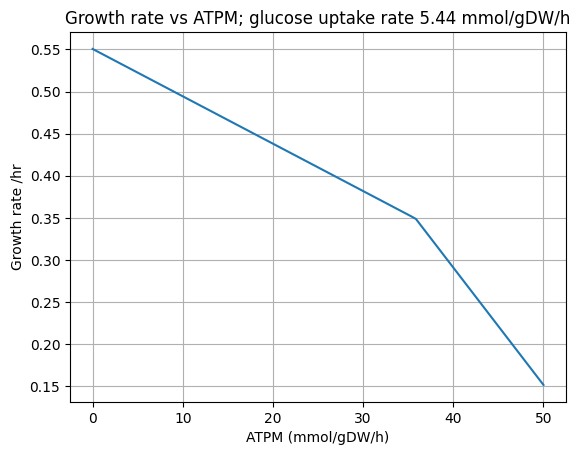

In [28]:
plt.plot(ATPM_space, growth_rates)
plt.xlabel("ATPM (mmol/gDW/h)")
plt.ylabel("Growth rate /hr")
plt.title("Growth rate vs ATPM; glucose uptake rate 5.44 mmol/gDW/h")
plt.grid(True)
plt.show()


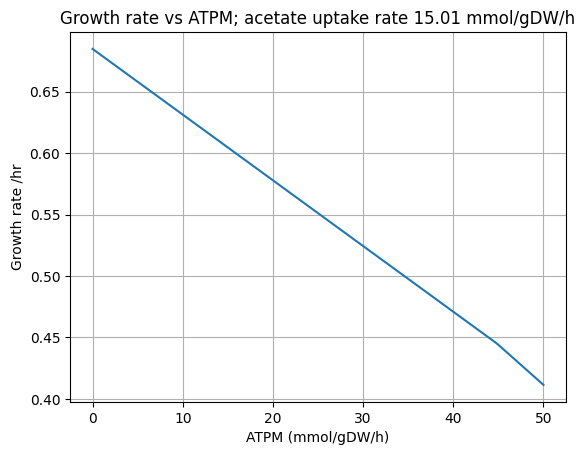

In [17]:
plt.plot(ATPM_space, growth_rates_ac)
plt.xlabel("ATPM (mmol/gDW/h)")
plt.ylabel("Growth rate /hr")
plt.title("Growth rate vs ATPM; acetate uptake rate 15.01 mmol/gDW/h")
plt.grid(True)
plt.show()
